# Setup

In [2]:
# Create the virtual environment
# python -m venv nlp_report

# Activate the environment (Mac/Linux)
# source nlp_report/bin/activate

# Install the Jupyter kernel bridge
# pip install ipykernel

# Register the environment as a Jupyter Kernel
# python -m ipykernel install --user --name=nlp_report --display-name="NLP Propaganda Report"

In [271]:
%pip -q install pandas matplotlib seaborn scikit-learn nltk spacy ollama ipywidgets groq openai numpy dotenv torch gensim


[notice] A new release of pip is available: 25.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 13.5 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 25.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [5]:
!pip freeze > requirements.txt

# Dataset

## Reading Data

In [2]:
import pandas as pd
import csv

# Define your file path
file_path = './propaganda_dataset_v2/propaganda_train.tsv'

# FIX: Add quoting=3 (csv.QUOTE_NONE) to treat quotes as literal text
# This prevents quotes from swallowing newlines and tabs across rows
df = pd.read_csv(file_path, sep='\t', quoting=3)

# Print a quick summary to see the newly restored row count
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2560 entries, 0 to 2559
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   label              2560 non-null   str  
 1   tagged_in_context  2560 non-null   str  
dtypes: str(2)
memory usage: 40.1 KB


In [3]:
display(df.head())

,label,tagged_in_context
0,not_propaganda,"No, <BOS> he <EOS> will not be confirmed."
1,not_propaganda,This declassification effort <BOS> won’t make ...
2,flag_waving,"""The Obama administration misled the <BOS> Ame..."
3,not_propaganda,“It looks like we’re capturing the demise of t...
4,not_propaganda,"<BOS> Location: Westerville, Ohio <EOS>"


In [4]:
for i in range(3):
    print(df['tagged_in_context'][i])

No, <BOS> he <EOS> will not be confirmed. 
This declassification effort <BOS> won’t make things any worse than they are for President Trump. <EOS> 
"The Obama administration misled the <BOS> American people <EOS> and Congress because they were desperate to get a deal with Iran," said Sen. 


## Data Cleaning

Apply cleaning to the full, pre-tokenized sequence. Focus on removing digital artifiacts and variations as these do not refect the language itself.

In [5]:
import html

# Replace all types of line breaks with a space
df['tagged_in_context'] = df['tagged_in_context'].str.replace(r'[\n\r]+', ' ', regex=True)

# Strip leading/trailing whitespace that might be left over
df['tagged_in_context'] = df['tagged_in_context'].str.strip()

# Remove html Artifacts
df['tagged_in_context'] = df['tagged_in_context'].apply(html.unescape)

# Standardize Quotation Marks
def standardize_quotes(text):
    text = text.replace('“', '"').replace('”', '"')
    text = text.replace('‘', "'").replace('’', "'")
    return text

df['tagged_in_context'] = df['tagged_in_context'].apply(standardize_quotes)

# Remove non-ascii characters 
df['tagged_in_context'] = df['tagged_in_context'].str.encode('ascii', 'ignore').str.decode('ascii')

## Column Unpacking

In [6]:
import nltk
import re

def get_span_indices(text):
    if pd.isna(text) or not isinstance(text, str):
        return (None, None), []
    
    safe_text = text.replace('<BOS>', ' __BOS__ ').replace('<EOS>', ' __EOS__ ')

    raw_tokens = nltk.word_tokenize(safe_text)

    try:
        start_tag_idx = raw_tokens.index('__BOS__')
        end_tag_idx = raw_tokens.index('__EOS__')
    except ValueError:
        # Fallback tracking guard if a row has malformed, single, or missing tags
        clean_tokens = [t for t in raw_tokens if t not in ('__BOS__', '__EOS__')]
        return (None, None), clean_tokens
    
    start_idx = start_tag_idx
    end_idx = end_tag_idx - 2 # storing indices as inclusive is nlp convention is to do (x, y+1) to use

    full_tokens = [t for t in raw_tokens if t not in ('__BOS__', '__EOS__')]

    return (start_idx, end_idx), full_tokens

In [7]:
# Apply the enrichment
df['span_info'] = df['tagged_in_context'].apply(get_span_indices)
df['span_info']

# Unpack for easier EDA
df['span_bounds'] = df['span_info'].apply(lambda x: x[0])
df['all_tokens'] = df['span_info'].apply(lambda x: x[1])

del df['span_info']

df.head(5)

,label,tagged_in_context,span_bounds,all_tokens
0,not_propaganda,"No, <BOS> he <EOS> will not be confirmed.","(2, 2)","[No, ,, he, will, not, be, confirmed, .]"
1,not_propaganda,This declassification effort <BOS> won't make ...,"(3, 15)","[This, declassification, effort, wo, n't, make..."
2,flag_waving,"""The Obama administration misled the <BOS> Ame...","(6, 7)","[``, The, Obama, administration, misled, the, ..."
3,not_propaganda,"""It looks like we're capturing the demise of t...","(14, 14)","[``, It, looks, like, we, 're, capturing, the,..."
4,not_propaganda,"<BOS> Location: Westerville, Ohio <EOS>","(0, 4)","[Location, :, Westerville, ,, Ohio]"


## Column Enriching

#### POS Enrichment

In [8]:
import nltk

# Ensure the POS tagger is downloaded
nltk.download('averaged_perceptron_tagger')

def get_pos_list(tokens):
    # nltk.pos_tag returns a list of tuples: [('word', 'TAG'), ...]
    # We only want the tags to keep the column clean for EDA
    tags = [tag for word, tag in nltk.pos_tag(tokens)]
    return tags

# Apply to the already tokenized all_tokens column
df['all_pos_tokens'] = df['all_tokens'].apply(get_pos_list)

# Verify the result
df.head(4)

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/lukebirkett/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


,label,tagged_in_context,span_bounds,all_tokens,all_pos_tokens
0,not_propaganda,"No, <BOS> he <EOS> will not be confirmed.","(2, 2)","[No, ,, he, will, not, be, confirmed, .]","[DT, ,, PRP, MD, RB, VB, VBN, .]"
1,not_propaganda,This declassification effort <BOS> won't make ...,"(3, 15)","[This, declassification, effort, wo, n't, make...","[DT, NN, NN, MD, RB, VB, NNS, DT, JJR, IN, PRP..."
2,flag_waving,"""The Obama administration misled the <BOS> Ame...","(6, 7)","[``, The, Obama, administration, misled, the, ...","[``, DT, NNP, NN, VBD, DT, JJ, NNS, CC, NNP, I..."
3,not_propaganda,"""It looks like we're capturing the demise of t...","(14, 14)","[``, It, looks, like, we, 're, capturing, the,...","[``, PRP, VBZ, IN, PRP, VBP, VBG, DT, NN, IN, ..."


#### Named Entity Tagging

In [9]:
import spacy
from spacy.tokens import Doc
import pandas as pd

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

def get_ner_tags_fixed(tokens):
    # Safety Check: If tokens is not a valid list, return an empty list
    if not isinstance(tokens, list):
        return []
        
    # FORCE SPACY TO USE YOUR EXACT NLTK TOKENS
    # This prevents spaCy from re-tokenizing the string and breaking alignments
    doc = Doc(nlp.vocab, words=tokens)
    
    # Run the rest of the spaCy pipeline components (like the NER tagger) over the doc
    for name, proc in nlp.pipeline:
        doc = proc(doc)
        
    # Build your matching 'O' array
    entities = ['O'] * len(tokens)
    
    # Map entities safely onto your exact token array slots
    for ent in doc.ents:
        for i in range(ent.start, ent.end):
            if i < len(entities):
                entities[i] = ent.label_
                
    return entities

In [10]:
# Apply the enrichment safely to the silver dataset, bypassing NaN rows
df['all_ner_tokens'] = df['all_tokens'].apply(
    lambda x: get_ner_tags_fixed(x) if isinstance(x, list) else None
)

df.head(5)

,label,tagged_in_context,span_bounds,all_tokens,all_pos_tokens,all_ner_tokens
0,not_propaganda,"No, <BOS> he <EOS> will not be confirmed.","(2, 2)","[No, ,, he, will, not, be, confirmed, .]","[DT, ,, PRP, MD, RB, VB, VBN, .]","[O, O, O, O, O, O, O, O]"
1,not_propaganda,This declassification effort <BOS> won't make ...,"(3, 15)","[This, declassification, effort, wo, n't, make...","[DT, NN, NN, MD, RB, VB, NNS, DT, JJR, IN, PRP...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, PER..."
2,flag_waving,"""The Obama administration misled the <BOS> Ame...","(6, 7)","[``, The, Obama, administration, misled, the, ...","[``, DT, NNP, NN, VBD, DT, JJ, NNS, CC, NNP, I...","[O, O, PERSON, O, O, O, NORP, O, O, ORG, O, O,..."
3,not_propaganda,"""It looks like we're capturing the demise of t...","(14, 14)","[``, It, looks, like, we, 're, capturing, the,...","[``, PRP, VBZ, IN, PRP, VBP, VBG, DT, NN, IN, ...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ..."
4,not_propaganda,"<BOS> Location: Westerville, Ohio <EOS>","(0, 4)","[Location, :, Westerville, ,, Ohio]","[NN, :, NNP, ,, NNP]","[O, O, GPE, O, GPE]"


In [11]:
# Check if the number of unique lengths across the three columns is 1 for every row
is_aligned = df.apply(lambda r: len({len(r['all_tokens']), len(r['all_pos_tokens']), len(r['all_ner_tokens'])}) == 1, axis=1)

print(f"✅ All {len(df)} rows aligned!" if is_aligned.all() else f"❌ Mismatches found in {len(df[~is_aligned])} rows")

✅ All 2560 rows aligned!


#### Phase 1: Distribution & Sequence EDA

1. [**Class Imbalance Check:**](#1-class-imbalance-check)
2. [**The "Snippet-to-Sentence" Ratio:**](#2-the-snippet-to-sentence-ratio)
3. [**Sequence Length Density:**](#3-sequence-length-density)
4. [**Summary Statistics for Snippet Length:**](#summary-statistics-for-the-snippet-length)
5. [**Summary Statistics for Context Length:**](#summary-statistics-for-the-snippet-length)
6. [**Distribution of Context Left vs Right:**](#6-distribution-of-context-left-vs-right)

---

##### 1. Class Imbalance Check:

Visualize the count of each label and the total data instances. 

###### Code

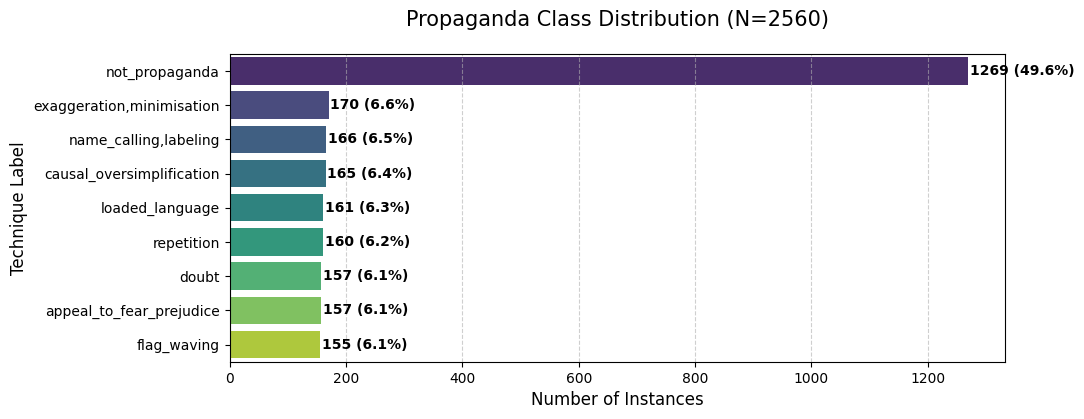

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate counts and percentages
label_counts = df['label'].value_counts()
label_pcts = df['label'].value_counts(normalize=True) * 100

# 2. Plotting
plt.figure(figsize=(10, 4))
ax = sns.barplot(x=label_counts.values, y=label_counts.index, hue=label_counts.index, palette='viridis', legend=False)

# Add value labels to the end of each bar
for i, v in enumerate(label_counts.values):
    ax.text(v + 3, i, f'{v} ({label_pcts.iloc[i]:.1f}%)', color='black', va='center', fontweight='bold')

plt.title(f'Propaganda Class Distribution (N={len(df)})', fontsize=15, pad=20)
plt.xlabel('Number of Instances', fontsize=12)
plt.ylabel('Technique Label', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

###### Results

- This is important insight for evaluation metric considersations (macro-f1) and loss functions (i.e. Weighted Cross Entropy)
- The dataset is small which each label only around 160 instances. 
- `not_propaganda` is the majorty label making up almost half the instances. Not considered by task 1 but might have impacts for Task 2
- The rest of the classes are remarkably balances which is in contrast to Sem-Eval 2020 task 11 and most propaganda datasets. 
- Impacts goal/desire for silver data creation. Previous had intended to balance the classes but now generation need to be balanced itself to maintin the structure
- Although Macro-F1 should allow fair comparison to the Gold dataset if the silver is imbalanced. 

---

##### 2. The "Snippet-to-Sentence" Ratio:

What percentage of the full_sequence is actually the snippet

*This is a critical metric for understanding the "density" of the propaganda. A low ratio indicates that the propaganda is a small part of a larger, potentially neutral, context (the "needle in a haystack" problem), while a high ratio suggests the propaganda is the primary focus of the sequence.*

###### Code

/var/folders/q9/kmgt4jcs40qbkm14m7p96ld40000gn/T/ipykernel_54990/1128258906.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='snippet_ratio', y='label', palette='mako', order=ratio_stats.index)


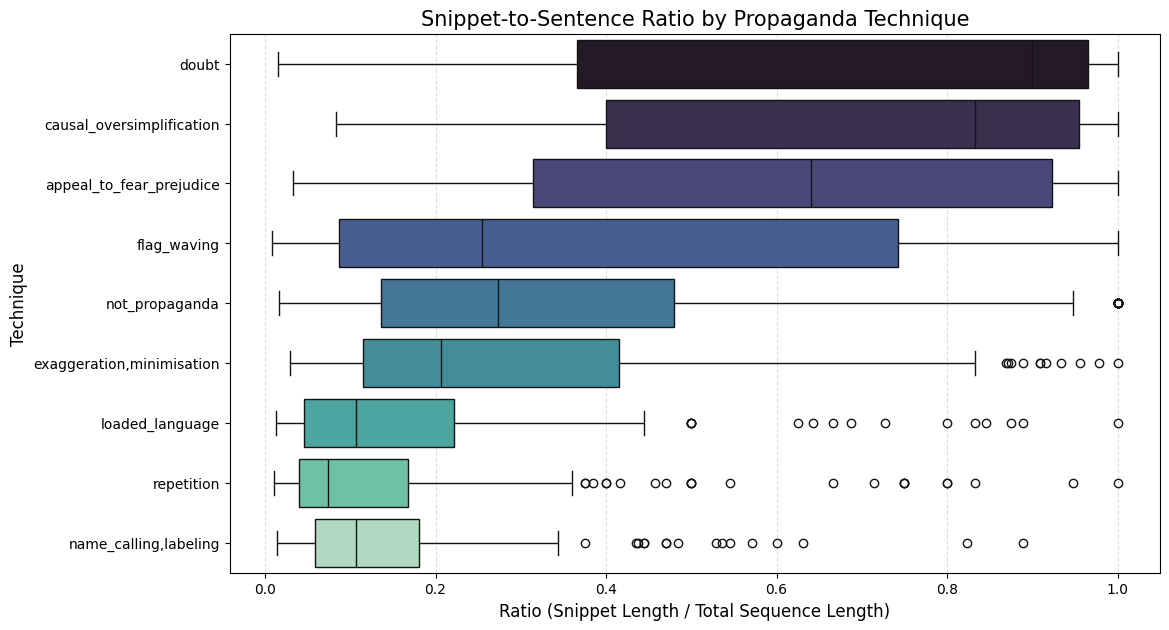

Average Snippet-to-Sentence Ratio per Label:
label
doubt                        0.700
causal_oversimplification    0.692
appeal_to_fear_prejudice     0.603
flag_waving                  0.389
not_propaganda               0.324
exaggeration,minimisation    0.302
loaded_language              0.176
repetition                   0.161
name_calling,labeling        0.155
Name: snippet_ratio, dtype: float64


In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the lengths and the ratio
# Note: x[1] is end_idx, x[0] is start_idx. Span is inclusive, so +1.
df['snippet_token_count'] = df['span_bounds'].apply(lambda x: x[1] - x[0] + 1)
df['total_token_count'] = df['all_tokens'].apply(len)
df['snippet_ratio'] = df['snippet_token_count'] / df['total_token_count']

# 2. Calculate the mean ratio per label for the plot
ratio_stats = df.groupby('label')['snippet_ratio'].mean().sort_values(ascending=False)

# 3. Visualization
plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x='snippet_ratio', y='label', palette='mako', order=ratio_stats.index)
plt.title('Snippet-to-Sentence Ratio by Propaganda Technique', fontsize=15)
plt.xlabel('Ratio (Snippet Length / Total Sequence Length)', fontsize=12)
plt.ylabel('Technique', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.show()

# 4. Display the average ratio numerically
print("Average Snippet-to-Sentence Ratio per Label:")
print(ratio_stats.round(3))

###### Results

- `causal_oversimplification` (0.698) and `doubt` (0.685) have the highest ratios.
- This means the propaganda makes up the bulk of the sentence.
- This probably tasks 1 harder if we think that the context is valuble.
- But may make Task 2's Span Identifcation easier as the snippet is more defined and there is less substrate (comparatively) to choose from. 
- `repetition` (0.158), `name_calling,labeling` (0.159), and `loaded_language` (0.178) have the lowest ratios.
- This might be a sign that the H1 will hold very strong for some categories.

---

##### 3. Sequence Length Density

Plot the distribution of all_tokens lengths vs. snippet lengths.

###### Code

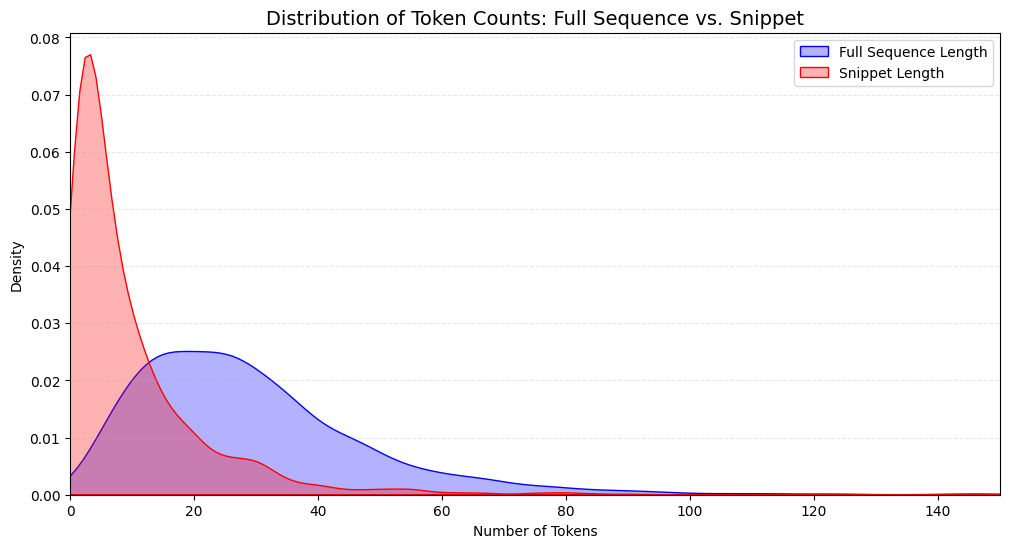

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate token counts for snippet and the full sequence
df['snippet_len'] = df['span_bounds'].apply(lambda x: x[1] - x[0] + 1)
df['full_len'] = df['all_tokens'].apply(len)
df['context_len'] = df['full_len'] - df['snippet_len']

# --- 3. Sequence Length Density Plot ---
plt.figure(figsize=(12, 6))
sns.kdeplot(df['full_len'], label='Full Sequence Length', fill=True, color='blue', alpha=0.3)
sns.kdeplot(df['snippet_len'], label='Snippet Length', fill=True, color='red', alpha=0.3)
plt.title('Distribution of Token Counts: Full Sequence vs. Snippet', fontsize=14)
plt.xlabel('Number of Tokens')
plt.ylabel('Density')
plt.xlim(0, 150) # Clipping for readability, as we know outliers exist
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

###### Results

---

##### 4 & 5: Summary Statistics Tables

###### Code

In [105]:
# --- 4 & 5. Summary Statistics Tables ---
snippet_stats = df.groupby('label')['snippet_len'].agg(['count', 'mean', 'std', 'min', 'max']).round(2)
context_stats = df.groupby('label')['context_len'].agg(['count', 'mean', 'std', 'min', 'max']).round(2)

print("--- ITEM 4: Snippet Length Statistics ---")
display(snippet_stats.sort_values(by='mean', ascending=False))

print("\n--- ITEM 5: Context Length Statistics ---")
display(context_stats.sort_values(by='mean', ascending=False))

--- ITEM 4: Snippet Length Statistics ---


,count,mean,std,min,max
label,,,,,
causal_oversimplification,165,23.22,14.85,3,86
doubt,157,22.60,20.35,1,160
appeal_to_fear_prejudice,157,19.08,13.75,1,80
flag_waving,155,11.62,13.90,1,79
"exaggeration,minimisation",170,8.12,6.07,1,45
not_propaganda,1269,7.20,7.81,1,91
"name_calling,labeling",166,4.64,3.76,1,24
loaded_language,161,3.78,3.64,1,30
repetition,160,3.08,4.29,1,38



--- ITEM 5: Context Length Statistics ---


,count,mean,std,min,max
label,,,,,
"name_calling,labeling",166,33.82,22.55,1,139
loaded_language,161,27.59,18.23,0,89
"exaggeration,minimisation",170,26.81,19.30,0,85
repetition,160,25.02,18.27,0,121
flag_waving,155,22.93,20.78,0,120
not_propaganda,1269,16.57,12.18,0,86
causal_oversimplification,165,14.15,19.22,0,110
appeal_to_fear_prejudice,157,14.14,15.17,0,72
doubt,157,13.01,21.39,0,134


###### Summary Stats with Long Instances Removed

In [106]:
# 1. Create a filtered version of the dataframe
# This excludes the extreme outliers (> 512 tokens)
df_clean = df[df['context_len'] <= 512].copy()

# 2. Run the statistics on the cleaned data
clean_snippet_stats = df_clean.groupby('label')['snippet_len'].agg(['count', 'mean', 'std', 'min', 'max']).round(2)
clean_context_stats = df_clean.groupby('label')['context_len'].agg(['count', 'mean', 'std', 'min', 'max']).round(2)

# 3. Output results
print(f"Summary Stats (Excluding {len(df) - len(df_clean)} outliers with Context > 512)")

print("\n--- CLEANED Snippet Length Statistics ---")
display(clean_snippet_stats.sort_values(by='mean', ascending=False))

print("\n--- CLEANED Context Length Statistics ---")
display(clean_context_stats.sort_values(by='mean', ascending=False))

Summary Stats (Excluding 0 outliers with Context > 512)

--- CLEANED Snippet Length Statistics ---


,count,mean,std,min,max
label,,,,,
causal_oversimplification,165,23.22,14.85,3,86
doubt,157,22.60,20.35,1,160
appeal_to_fear_prejudice,157,19.08,13.75,1,80
flag_waving,155,11.62,13.90,1,79
"exaggeration,minimisation",170,8.12,6.07,1,45
not_propaganda,1269,7.20,7.81,1,91
"name_calling,labeling",166,4.64,3.76,1,24
loaded_language,161,3.78,3.64,1,30
repetition,160,3.08,4.29,1,38



--- CLEANED Context Length Statistics ---


,count,mean,std,min,max
label,,,,,
"name_calling,labeling",166,33.82,22.55,1,139
loaded_language,161,27.59,18.23,0,89
"exaggeration,minimisation",170,26.81,19.30,0,85
repetition,160,25.02,18.27,0,121
flag_waving,155,22.93,20.78,0,120
not_propaganda,1269,16.57,12.18,0,86
causal_oversimplification,165,14.15,19.22,0,110
appeal_to_fear_prejudice,157,14.14,15.17,0,72
doubt,157,13.01,21.39,0,134


###### Results

- high std for length will impact the class based performance as their it high structural variablilty between the instances. 
- Remove the extra long string reins in the std significantly
- There are a handful of obscently high context length. transfors has a hard limit of 512 but perform more efficently at lower max lengths (i think?).
- When truncating during training will need to devise i way to make sure the snippit isn't truncated. 
- Probably a middle out approach but this risk sacrifing the beginging and end context which for some instances will be the most important. 
- Could look into an augmentation approach if there is enough volumne. 

###### Count Number of Long Context Windows

There are only 3

In [107]:
# 1. Calculate full context length (Left + Right tokens)
# Using our 'all_tokens' and 'span_bounds' logic:
df['context_len'] = df['all_tokens'].apply(len) - (df['span_bounds'].apply(lambda x: x[1] - x[0] + 1))

# 2. Filter for instances exceeding the 512-token limit
long_context_mask = df['context_len'] > 512
long_context_df = df[long_context_mask]

# 3. Print the results
print(f"Total instances with context > 512 tokens: {len(long_context_df)}")

if not long_context_df.empty:
    print("\nBreakdown by Label:")
    print(long_context_df['label'].value_counts())
    
    # Optional: Display the specific rows to see how 'extreme' they are
    display(long_context_df[['label', 'context_len', 'all_tokens']].head())
else:
    print("No instances found exceeding the 512-token threshold.")

Total instances with context > 512 tokens: 0
No instances found exceeding the 512-token threshold.


---

##### 6. Distribution of Context Left vs Right

Do any of the classes exhibit a skew for context on onside? this also tell us if any classes as a bias for the snipper position, i.e. at the end after rhetoric buildup where the context will be very important.

###### Code

--- SEQUENCE ANATOMY: AVERAGE TOKEN COUNTS PER LABEL ---


,left_context_len,snippet_len,right_context_len,Symmetry_Index
label,,,,
"name_calling,labeling",18.62,4.64,15.20,0.55
causal_oversimplification,7.74,23.22,6.41,0.55
doubt,7.04,22.60,5.97,0.54
"exaggeration,minimisation",14.75,8.12,12.06,0.55
flag_waving,14.17,11.62,8.76,0.62
appeal_to_fear_prejudice,9.08,19.08,5.06,0.64
loaded_language,15.94,3.78,11.65,0.58
repetition,12.34,3.08,12.68,0.49
not_propaganda,9.92,7.20,6.66,0.60


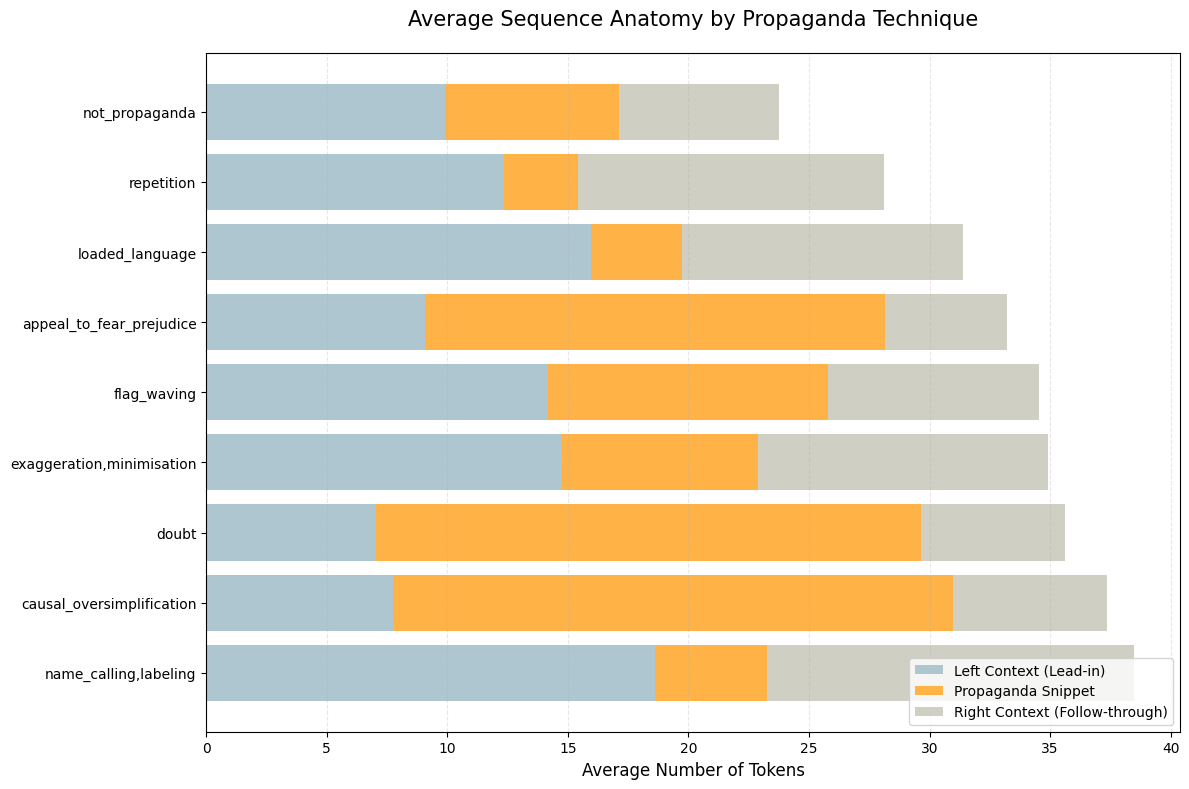

In [108]:
import pandas as pd
import matplotlib.pyplot as plt

df_clean['left_context_len'] = df['span_bounds'].apply(
    lambda x: x[0] if isinstance(x, tuple) and x[0] is not None else 0
)
df_clean['right_context_len'] = df.apply(
    lambda r: len(r['all_tokens']) - (r['span_bounds'][1] + 1) 
    if isinstance(r['span_bounds'], tuple) and r['span_bounds'][1] is not None else 0, 
    axis=1
)

# 1. Aggregate the means per label
comp_data = df_clean.groupby('label')[['left_context_len', 'snippet_len', 'right_context_len']].mean()

# 2. Calculate the Symmetry Index
comp_data['Symmetry_Index'] = (comp_data['left_context_len'] / 
                              (comp_data['left_context_len'] + comp_data['right_context_len'])).round(3)

# 3. Calculate Total Length for sorting
comp_data['Total_Avg_Len'] = comp_data.sum(axis=1)
comp_data = comp_data.sort_values('Total_Avg_Len', ascending=False)

# 4. Display the table for quoting in the report
print("--- SEQUENCE ANATOMY: AVERAGE TOKEN COUNTS PER LABEL ---")
display(comp_data[['left_context_len', 'snippet_len', 'right_context_len', 'Symmetry_Index']].round(2))

# 5. Visualization (Horizontal Stacked Bar)
plt.figure(figsize=(12, 8))
labels = comp_data.index
left = comp_data['left_context_len']
snippet = comp_data['snippet_len']
right = comp_data['right_context_len']

plt.barh(labels, left, color='#aec6cf', label='Left Context (Lead-in)')
plt.barh(labels, snippet, left=left, color='#ffb347', label='Propaganda Snippet')
plt.barh(labels, right, left=left+snippet, color='#cfcfc4', label='Right Context (Follow-through)')

plt.title('Average Sequence Anatomy by Propaganda Technique', fontsize=15, pad=20)
plt.xlabel('Average Number of Tokens', fontsize=12)
plt.legend(loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

$$Symmetry = \frac{Mean\_Left}{Mean\_Left + Mean\_Right}$$
- If $Symmetry \approx 0.5$, the technique is "Context Independent."
- If $Symmetry > 0.6$, the technique is "Narrative-Driven" (needs lead-in).

###### Results

- structurally quite different. this should be good for the span identification. 
    - doubt and casual both balanced and snippet heavy.
    - repetition, loaded, name_called all mid snippet but vary slightly in the skew and composition.
- there are few that are similar in composition which would be good to compare in the analysis to see if the models mis-classify or mis-label.

---

#### Phase 2: Lexical & Morphological EDA (H1 Testing)

7. [**POS Tag Distribution (Heatmap):**](#7-pos-tag-distribution-heatmap)
8. [**Proper Noun Analysis (NER):**](#8-proper-noun-analysis-ner)
9. [**Unique N-Gram Analysis:**](#9-unique-n-gram-analysis)

----

##### 7. POS Tag Distribution (Heatmap):

Compare the frequency of POS tags (JJ, NNP, VB, etc.) within the snippets for each label.

###### Code

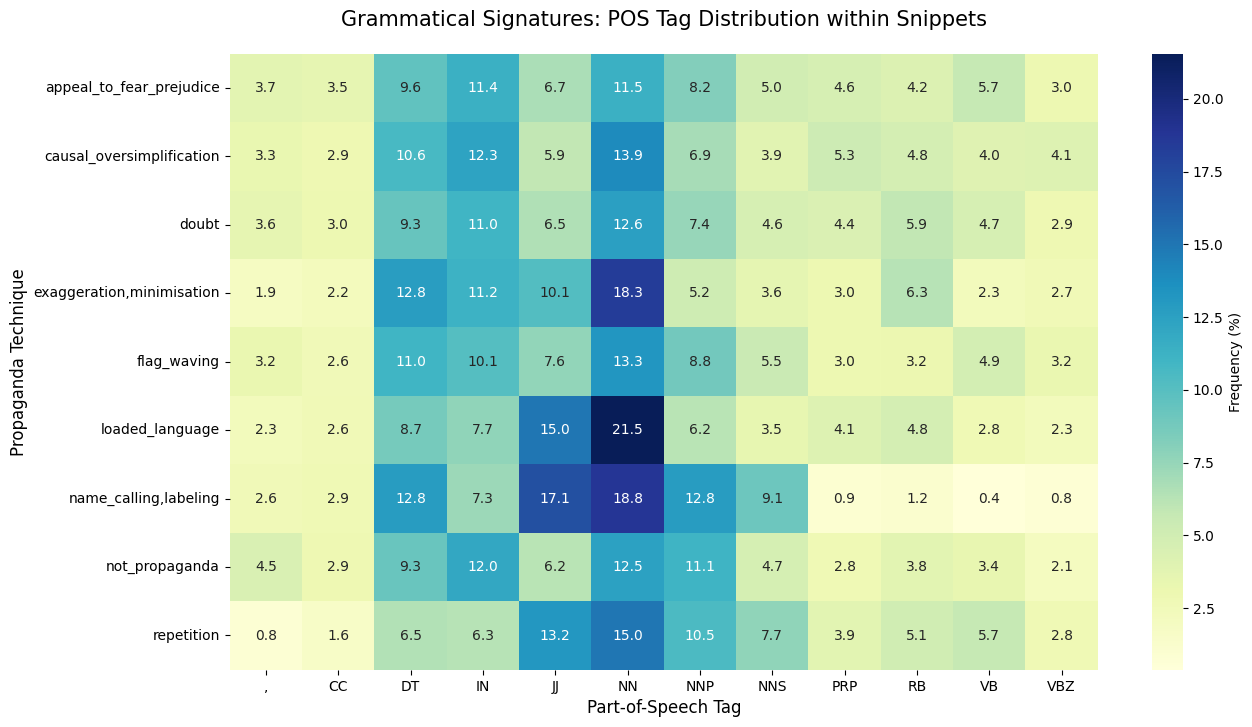

In [109]:
from collections import Counter
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Isolate the POS tags specifically inside the snippets
def get_snippet_pos(row):
    start, end = row['span_bounds']
    return row['all_pos_tokens'][start : end + 1]

df_clean['snippet_pos'] = df_clean.apply(get_snippet_pos, axis=1)

# 2. Flatten the POS tags by label and count them
pos_by_label = []
for label in df_clean['label'].unique():
    # Combine all POS tags for this label into one long list
    all_tags = [tag for sublist in df_clean[df_clean['label'] == label]['snippet_pos'] for tag in sublist]
    counts = Counter(all_tags)
    total = sum(counts.values())
    
    # Calculate percentage for each tag
    for tag, count in counts.items():
        pos_by_label.append({
            'Label': label,
            'POS_Tag': tag,
            'Frequency (%)': (count / total) * 100
        })

pos_df = pd.DataFrame(pos_by_label)

# 3. Pivot the data for the heatmap
# We'll filter for the most common POS tags to keep the heatmap readable
top_tags = pos_df.groupby('POS_Tag')['Frequency (%)'].sum().sort_values(ascending=False).head(12).index
heatmap_data = pos_df[pos_df['POS_Tag'].isin(top_tags)].pivot(index='Label', columns='POS_Tag', values='Frequency (%)')

# 4. Plotting
plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Frequency (%)'})
plt.title('Grammatical Signatures: POS Tag Distribution within Snippets', fontsize=15, pad=20)
plt.xlabel('Part-of-Speech Tag', fontsize=12)
plt.ylabel('Propaganda Technique', fontsize=12)
plt.show()

--- CONTEXT POS DISTRIBUTION: AVERAGE FREQUENCY PER LABEL ---


POS_Tag,",",.,DT,IN,JJ,NN,NNP,NNS,PRP,RB,VB,VBD
Label,,,,,,,,,,,,
appeal_to_fear_prejudice,5.77,6.67,7.84,10.72,6.22,9.59,10.77,3.69,3.92,3.65,2.75,2.93
causal_oversimplification,5.70,7.41,8.53,11.05,6.00,10.67,9.64,4.84,2.61,3.51,2.66,2.91
doubt,5.04,7.34,9.15,10.96,5.34,12.33,9.84,3.77,2.20,4.31,2.89,3.13
"exaggeration,minimisation",5.40,3.91,9.02,11.85,6.01,11.54,10.27,3.80,3.36,3.40,3.49,3.23
flag_waving,4.67,4.45,8.47,11.09,5.15,10.66,11.20,4.28,2.84,4.22,3.32,2.76
loaded_language,4.50,3.74,9.41,11.19,6.06,11.66,10.60,4.41,2.93,4.21,2.84,2.41
"name_calling,labeling",5.31,3.19,8.64,11.24,5.20,10.90,10.69,3.71,3.01,3.94,3.30,2.80
not_propaganda,4.41,4.62,9.61,11.03,5.33,11.99,11.59,4.50,3.39,3.92,3.18,3.69
repetition,4.42,4.22,9.72,11.59,5.70,11.97,8.89,4.87,2.85,3.45,3.52,2.90


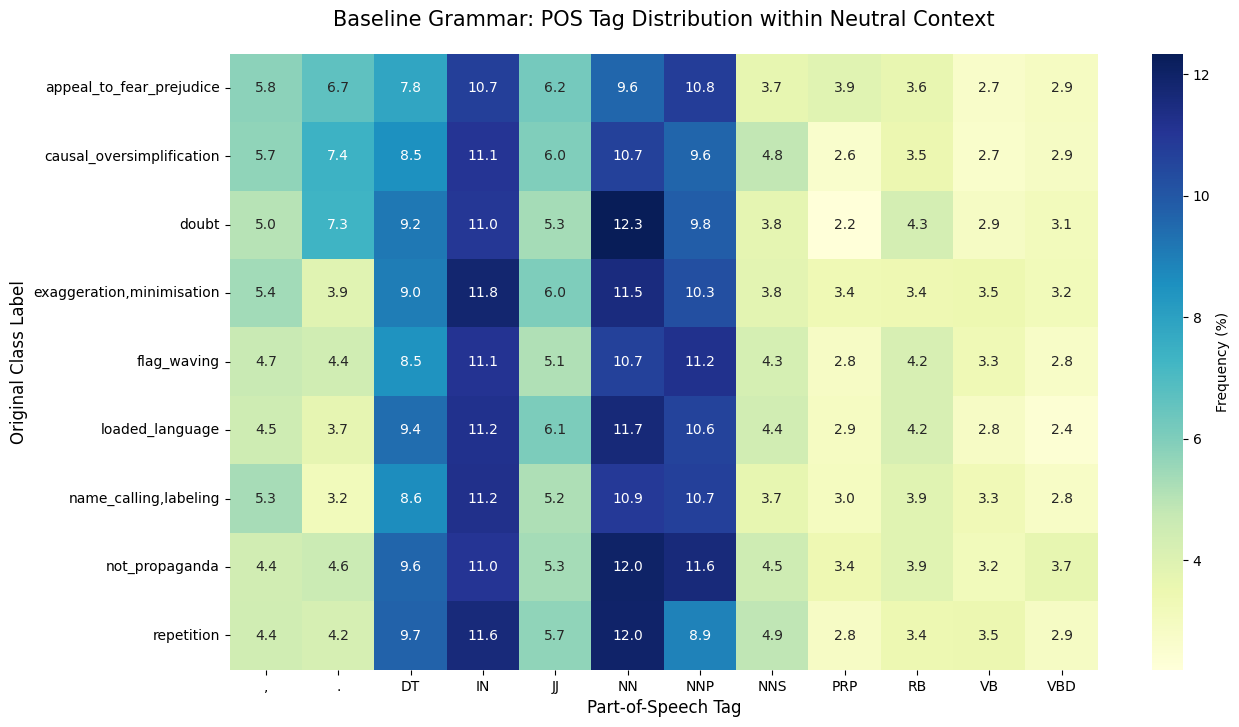

In [110]:
from collections import Counter
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Isolate the POS tags for the Context (Everything NOT in the span)
def get_context_pos(row):
    start, end = row['span_bounds']
    # Combine tokens from the left and right of the snippet
    return row['all_pos_tokens'][:start] + row['all_pos_tokens'][end + 1:]

df_clean['context_pos'] = df_clean.apply(get_context_pos, axis=1)

# 2. Flatten the POS tags by label and count them
context_pos_data = []
for label in df_clean['label'].unique():
    # Filter for rows with this label and collect context tags
    all_context_tags = [tag for sublist in df_clean[df_clean['label'] == label]['context_pos'] for tag in sublist]
    
    counts = Counter(all_context_tags)
    total = sum(counts.values()) if counts else 1 # Avoid division by zero
    
    for tag, count in counts.items():
        context_pos_data.append({
            'Label': label,
            'POS_Tag': tag,
            'Frequency (%)': (count / total) * 100
        })

context_pos_df = pd.DataFrame(context_pos_data)

# 3. Pivot the data for the heatmap
# Use the same 'top_tags' from the snippet analysis to ensure the comparison is direct
# (Assuming 'top_tags' was defined in the previous cell; if not, we define it here)
top_tags = context_pos_df.groupby('POS_Tag')['Frequency (%)'].sum().sort_values(ascending=False).head(12).index
ctx_heatmap_data = context_pos_df[context_pos_df['POS_Tag'].isin(top_tags)].pivot(index='Label', columns='POS_Tag', values='Frequency (%)')

# 4. Display the table for the report
print("--- CONTEXT POS DISTRIBUTION: AVERAGE FREQUENCY PER LABEL ---")
display(ctx_heatmap_data.round(2))

# 5. Plotting
plt.figure(figsize=(14, 8))
sns.heatmap(ctx_heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Frequency (%)'})
plt.title('Baseline Grammar: POS Tag Distribution within Neutral Context', fontsize=15, pad=20)
plt.xlabel('Part-of-Speech Tag', fontsize=12)
plt.ylabel('Original Class Label', fontsize=12)
plt.show()

###### Results

- the context POS for all labels is very consistent and similar thoughout. mostly nn, nnp, in and dt
- the snippets themselves are distributes wildly differently to the context
- firstly, this is important for task 2 because it means propaganda snippets should be clearly identifable and they are structually different to their surroundings. 
- secondly, the pos distributing is different between labels and within tags. 
- nn is still the most freq but there is a wide disparity within going from 20 to 10
- there are some deep categories for jj
- in and dt were very consistent for context but vary for snippet
- there are not . in the snippets meaning it does not occur at the every end of the sentence or accross sentences. 
- nnp its not clear definied as a strong category in the snippers where as it is top 4 in context. 
- rb and nns unique for some labels in snippet

---

##### 8. Proper Noun Analysis (NER):

Identify which entities (PERSON, ORG, GPE) appear most often within snippets.

###### code

"Unlike the POS analysis, which measures token-level distribution, the NER analysis measures Instance-level Presence. A score of 52.78% for 'PERSON' in the 'doubt' category indicates that over half of all snippets of this type target a specific individual. The non-summation to 100% reflects the fact that snippets may target multiple entity types simultaneously or contain no recognized entities at all."

--- NER ENTITY DENSITY: % OF SNIPPETS CONTAINING ENTITY TYPE ---


Entity,EVENT,FAC,GPE,NORP,ORG,PERSON,PRODUCT
Label,,,,,,,
appeal_to_fear_prejudice,1.91,0.00,43.31,30.57,43.31,17.20,0.00
causal_oversimplification,0.00,0.61,27.27,19.39,47.88,49.09,0.61
doubt,0.00,1.27,19.11,14.65,50.96,59.24,0.00
"exaggeration,minimisation",1.76,0.00,5.29,6.47,15.88,8.82,0.00
flag_waving,0.00,0.00,32.26,45.81,20.65,9.03,0.00
loaded_language,0.00,0.00,2.48,2.48,5.59,4.97,0.00
"name_calling,labeling",0.00,1.81,7.83,13.86,20.48,16.27,0.00
not_propaganda,0.08,0.87,13.00,6.46,31.84,20.80,0.39
repetition,0.00,1.25,1.88,3.12,5.00,6.88,0.62


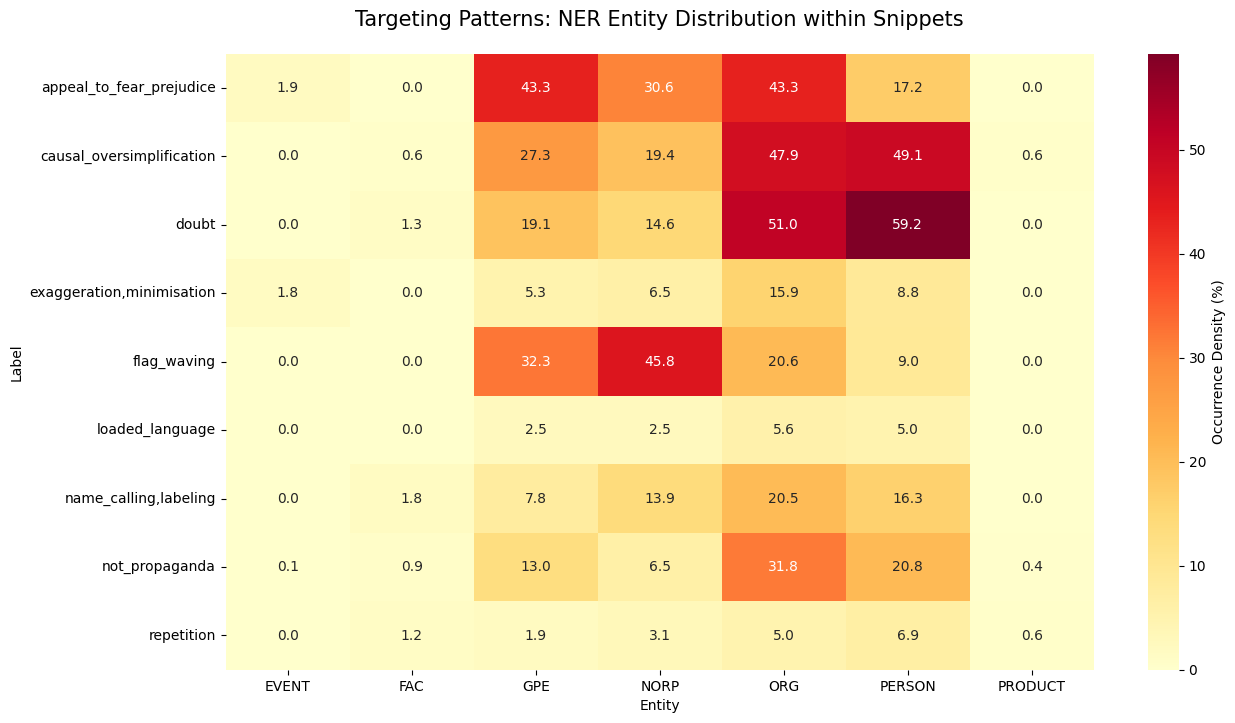

In [111]:
from collections import Counter
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Isolate the NER tags specifically inside the snippets
def get_snippet_ner(row):
    start, end = row['span_bounds']
    # Return unique entities found in the snippet (excluding 'O')
    return [tag for tag in row['all_ner_tokens'][start : end + 1] if tag != 'O']

df_clean['snippet_ner'] = df_clean.apply(get_snippet_ner, axis=1)

# 2. Calculate the "Entity Presence" per label
ner_stats = []
for label in df_clean['label'].unique():
    label_df = df_clean[df_clean['label'] == label]
    total_instances = len(label_df)
    
    # Count how many snippets in this label contain at least one of each entity type
    all_tags_in_label = [tag for sublist in label_df['snippet_ner'] for tag in sublist]
    tag_counts = Counter(all_tags_in_label)
    
    for tag, count in tag_counts.items():
        ner_stats.append({
            'Label': label,
            'Entity': tag,
            'Density (%)': (count / total_instances) * 100
        })

ner_df = pd.DataFrame(ner_stats)

# 3. Pivot for the heatmap
# We'll focus on the most relevant entities for propaganda analysis
target_entities = ['PERSON', 'ORG', 'GPE', 'NORP', 'FAC', 'PRODUCT', 'EVENT']
heatmap_ner = ner_df[ner_df['Entity'].isin(target_entities)].pivot(index='Label', columns='Entity', values='Density (%)').fillna(0)

# 4. Display numerical table for the report
print("--- NER ENTITY DENSITY: % OF SNIPPETS CONTAINING ENTITY TYPE ---")
display(heatmap_ner.round(2))

# 5. Plotting
plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_ner, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={'label': 'Occurrence Density (%)'})
plt.title('Targeting Patterns: NER Entity Distribution within Snippets', fontsize=15, pad=20)
plt.show()

###### results

##### 9. Unique N-Gram Analysis:

What are the top 2-word or 3-word phrases that only appear in specific propaganda classes? This probably wont be possible given the lack of data in each class but failure to produce good bi-grams or tri-grams means that such techniques will not be justifable later in the modelling phases, so important to highlight this now.

#### Phase 3: Structural & Positional EDA (H2 Testing)


10. [**Relative Position Analysis:**](#10-relative-position-analysis)

---

##### 10. Relative Position Analysis

Calculate start_idx / len(all_tokens). Plot this for each label.

###### code

$$\text{Relative Position} = \frac{\text{Start Index of Snippet}}{\text{Total Token Count of Sequence}}$$
- 0.0: Snippet starts at the very beginning of the sentence.
- 0.5: Snippet starts exactly in the middle.
- 1.0: Snippet is at the very end.

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate Relative Position
# (Start Index / Total Tokens)
df_clean['rel_position'] = df_clean['span_bounds'].apply(lambda x: x[0]) / df_clean['all_tokens'].apply(len)

# 2. Visualizing the "Stretch" with a Strip Plot + Box Plot
plt.figure(figsize=(12, 8))

# Boxplot shows the quartiles and medians
sns.boxplot(data=df_clean, x='rel_position', y='label', palette='vlag', whis=np.inf)

# Strip plot shows every single data point to visualize the "stretch"
sns.stripplot(data=df_clean, x='rel_position', y='label', color="black", size=2, alpha=0.3)

plt.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Sentence Middle')
plt.title('Positional Dispersion: Do Techniques Favor Specific Locations?', fontsize=15)
plt.xlabel('Relative Position (0.0 = Start, 1.0 = End)', fontsize=12)
plt.ylabel('Technique', fontsize=12)
plt.grid(axis='x', linestyle=':', alpha=0.5)
plt.show()

# 3. Calculate the "Dispersion" (Standard Deviation)
# High SD = "Stretch" (The technique can happen anywhere)
# Low SD = "Fixed" (The technique has a preferred location)
position_dispersion = df_clean.groupby('label')['rel_position'].agg(['mean', 'std', 'min', 'max']).round(3)
print("--- POSITIONAL DISPERSION TABLE ---")
display(position_dispersion.sort_values(by='std', ascending=False))

NameError: name 'np' is not defined

<Figure size 1200x800 with 0 Axes>

###### results

- definetly seems to be a bias towards starting early. 
- this could a be bias in the data collection itself, or a demonstration of the nuance of prop, as recipients may not realise it is happening at first.
- loaded_language is a clear outlier in the that is occur on average after the 0.5 middle
- name_called also exactly 0.5
- all of the rest of left skewed. 
- doubt, pred, and oversimple actually have their interquarile touching 0. 
- all have pretty consistent std meaning they are predictable within their own labels.

#### Phase 4: Correlation & Complexity

11. **Label Confusion (Theoretical):** Identify which labels share the most common words/POS tags.

---

##### 11. **Label Confusion (Theoretical):**

"By calculating the Theoretical Confusion, you are essentially identifying which labels look the same to a computer. If two labels have a 95% similarity in their POS and vocabulary, you can predict before training that your model will struggle to distinguish them."

###### code

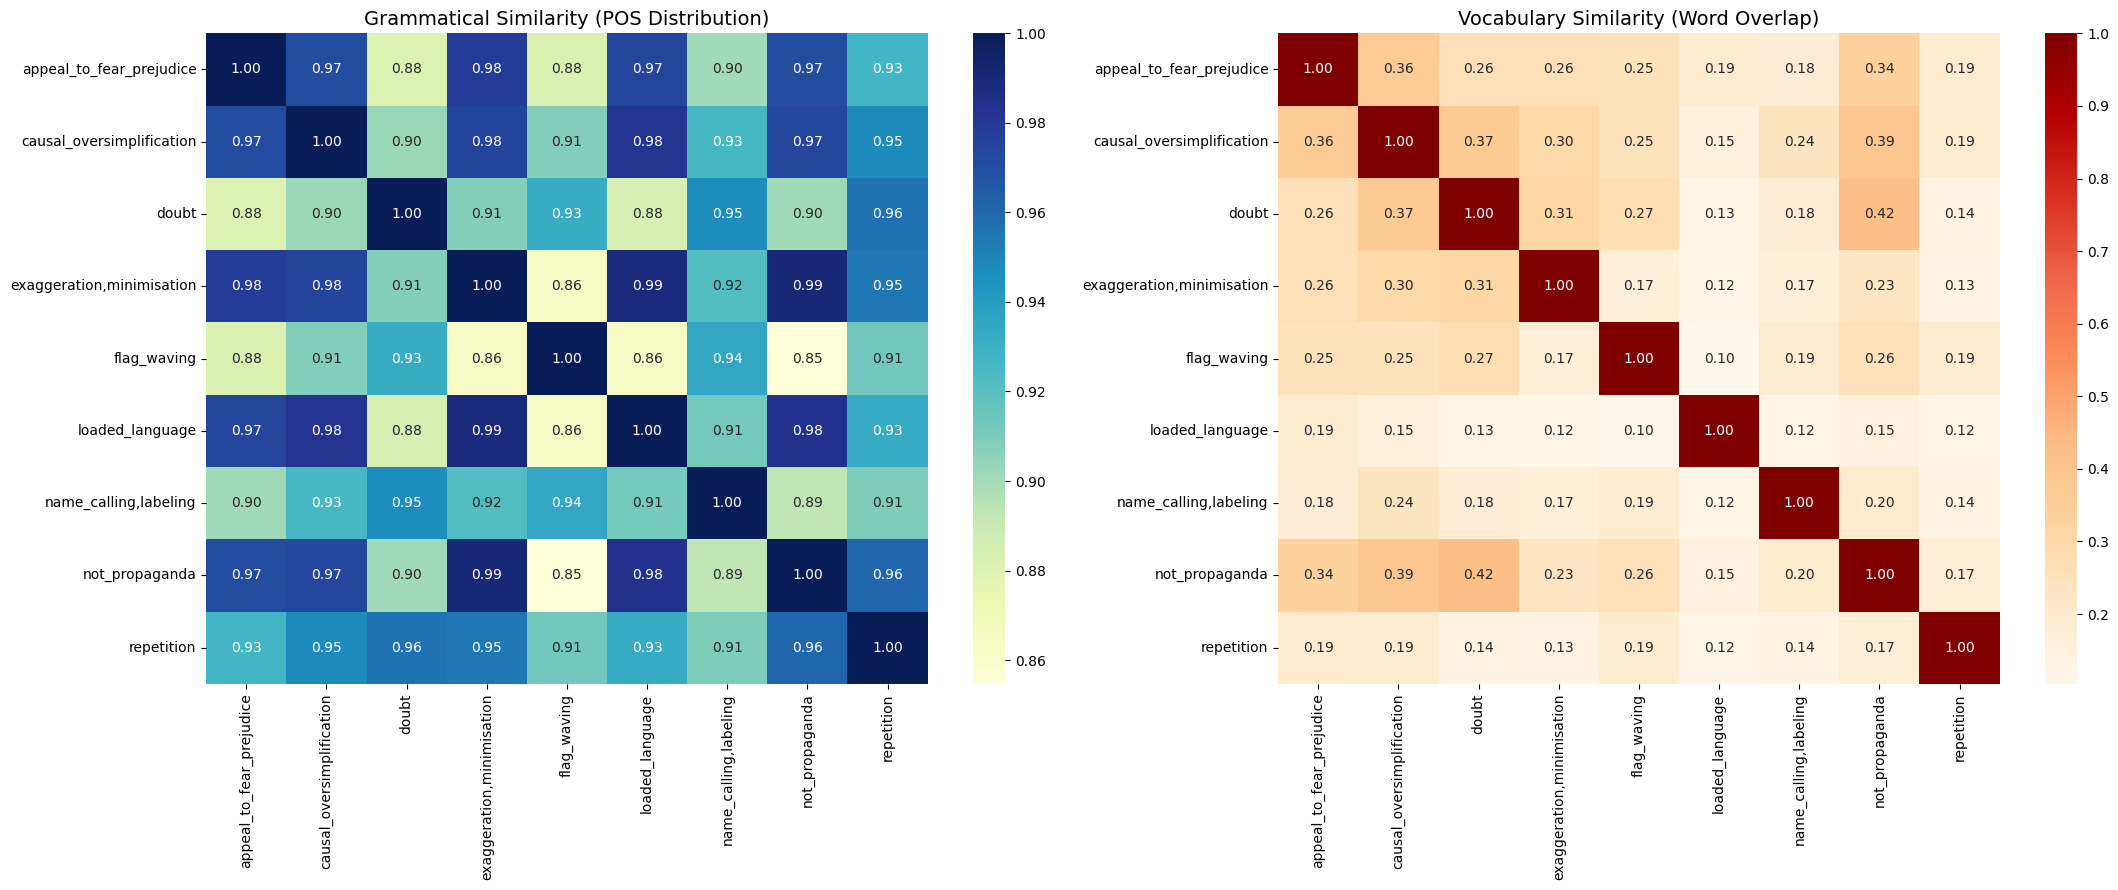

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Extraction Layer: Slicing snippets from the enriched sequences
# We use span_bounds (start, end) to pull exactly what the model will 'see'
def get_snippet_data(row):
    start, end = row['span_bounds']
    # Slicing is inclusive of the end index
    tokens = row['all_tokens'][start : end + 1]
    pos_tags = row['all_pos_tokens'][start : end + 1]
    return " ".join(tokens), pos_tags

# Create temporary columns for the analysis
# Use df_clean if you are working with the length-filtered dataset
df_analysis = df.copy() 
df_analysis[['snippet_text', 'snippet_pos']] = df_analysis.apply(
    lambda r: pd.Series(get_snippet_data(r)), axis=1
)

# 2. Morphological Similarity (POS Tags)
pos_profiles = []
unique_labels = df_analysis['label'].unique()

for label in unique_labels:
    # Flatten all snippet POS tags for this specific label
    all_tags = [tag for sublist in df_analysis[df_analysis['label'] == label]['snippet_pos'] for tag in sublist]
    counts = Counter(all_tags)
    total = sum(counts.values()) if counts else 1
    # Create a normalized distribution (0.0 to 1.0)
    profile = {tag: (count/total) for tag, count in counts.items()}
    profile['label'] = label
    pos_profiles.append(profile)

pos_dist_df = pd.DataFrame(pos_profiles).set_index('label').fillna(0)
pos_sim_matrix = cosine_similarity(pos_dist_df)

# 3. Lexical Similarity (Vocabulary)
# We treat all snippets of a label as one giant document
label_docs = df_analysis.groupby('label')['snippet_text'].apply(lambda x: " ".join(x.astype(str)))
vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
tfidf_matrix = vectorizer.fit_transform(label_docs)
lex_sim_matrix = cosine_similarity(tfidf_matrix)

# 4. Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9))

# POS Heatmap: Stylistic Overlap
sns.heatmap(pos_sim_matrix, annot=True, fmt=".2f", cmap='YlGnBu',
            xticklabels=label_docs.index, yticklabels=label_docs.index, ax=ax1)
ax1.set_title('Grammatical Similarity (POS Distribution)', fontsize=14)

# Lexical Heatmap: Word Overlap
sns.heatmap(lex_sim_matrix, annot=True, fmt=".2f", cmap='OrRd',
            xticklabels=label_docs.index, yticklabels=label_docs.index, ax=ax2)
ax2.set_title('Vocabulary Similarity (Word Overlap)', fontsize=14)

plt.tight_layout()
plt.show()

###### results

---

#### Dataset Artifact Cleanup

In [113]:
del df['snippet_token_count']
del df['total_token_count']
del df['snippet_ratio']
del df['snippet_len']
del df['full_len']
del df['context_len']

In [12]:
df.head(3)

,label,tagged_in_context,span_bounds,all_tokens,all_pos_tokens,all_ner_tokens
0,not_propaganda,"No, <BOS> he <EOS> will not be confirmed.","(2, 2)","[No, ,, he, will, not, be, confirmed, .]","[DT, ,, PRP, MD, RB, VB, VBN, .]","[O, O, O, O, O, O, O, O]"
1,not_propaganda,This declassification effort <BOS> won't make ...,"(3, 15)","[This, declassification, effort, wo, n't, make...","[DT, NN, NN, MD, RB, VB, NNS, DT, JJR, IN, PRP...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, PER..."
2,flag_waving,"""The Obama administration misled the <BOS> Ame...","(6, 7)","[``, The, Obama, administration, misled, the, ...","[``, DT, NNP, NN, VBD, DT, JJ, NNS, CC, NNP, I...","[O, O, PERSON, O, O, O, NORP, O, O, ORG, O, O,..."


---

## Data Augmentation

### Silver Dataset Generative Process

#### Ollama Terminal

In [73]:
# Download and install Ollama from ollama.com.

# !ollama run llama3

# !pip install ollama


# ollama pull dolphin-llama3

# https://ollama.com/library/dolphin-llama3

# dolphin-llama3:8b
# dolphin-llama3:70b

# ollama run dolphin-llama3:8b-256k
# >>> /set parameter num_ctx 256000

# response = ollama.chat(
        #     model='dolphin-llama3',  # <-- UPDATE THIS STRING HERE
        #     messages=messages,
        #     options={
        #         'temperature': temperature,
        #         'num_predict': 512,  
        #         'num_thread': 4,     
        #     }
        # )

# https://console.groq.com/home



#### Logger

In [13]:
import logging
import sys

# 1. Initialize a named logger (Leave global level at INFO so it captures everything)
logger = logging.getLogger("propaganda_logger")
logger.setLevel(logging.INFO)

# 2. Clear out any existing handlers (prevents duplicate logs when rerunning cells)
if logger.hasHandlers():
    logger.handlers.clear()

# 3. Create a File Handler (Saves EVERYTHING to your text file)
file_handler = logging.FileHandler("propaganda_augmentation.log", mode="a", encoding="utf-8")
file_formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
file_handler.setFormatter(file_formatter)
file_handler.setLevel(logging.INFO) # <--- Force the file to capture every single log trace
logger.addHandler(file_handler)

# 4. Create a Stream Handler (Controls live notebook console printing)
stream_handler = logging.StreamHandler(sys.stdout)
stream_formatter = logging.Formatter('%(message)s') 
stream_handler.setFormatter(stream_formatter)

# --- THE BIG RUN FIX ---
# Raise this to WARNING or ERROR. This tells the screen: 
# "Only interrupt my notebook if a row crashes or an API error occurs. Otherwise, stay quiet."
stream_handler.setLevel(logging.WARNING) 
logger.addHandler(stream_handler)

print("Logging system optimized for Batch Run! Detailed transcripts -> 'propaganda_augmentation.log'")

Logging system optimized for Batch Run! Detailed transcripts -> 'propaganda_augmentation.log'


#### Call Model Helper Function(s)

In [14]:
# import ollama
# from typing import Optional

# def call_llama(messages: list, temperature: float = 0.7) -> str:
#     """Helper function to call local Llama 3 and return the text content."""
    # try:
    #     response = ollama.chat(
    #         model='dolphin-llama3', 
    #         messages=messages,
    #         options={
    #             'temperature': temperature,
    #             # 'num_predict': 512,  # Caps output length
    #             # 'num_thread': 4,     # Hard-codes execution cores
    #         }
    #     )
    #     return response['message']['content'].strip()
    # except Exception as e:
    #     print(f"Ollama Connection Error: {e}")
    #     return ""

In [15]:
# from groq import Groq

# # Initialize client with your free API key
# groq_client = Groq(api_key="GROQ_KEY")

# def call_llama(messages: list, temperature: float = 0.7) -> str:
#     """Routes your exact same loop through Groq's blazing fast cloud hardware"""
#     try:
#         response = groq_client.chat.completions.create(
#             model='llama-3.1-8b-instant', 
#             messages=messages,
#             temperature=temperature,
#         )
#         return response.choices[0].message.content.strip()
#     except Exception as e:
#         print(f"Groq API Cloud Error: {e}")
#         return ""

In [16]:
from openai import OpenAI

import os
from dotenv import load_dotenv

# 1. This reads the hidden text file and injects the variables into system memory
load_dotenv()

# 2. This pulls the key string safely out of system memory
together_key = os.getenv("TOG_API_KEY")

# 3. Double check it worked (it shouldn't be None)
if together_key:
    print("[SUCCESS] API Key loaded into notebook background environment memory.")
else:
    print("[ERROR] Could not find TOGETHER_API_KEY. Check your .env file location!")



client = OpenAI(
    api_key=together_key,
    base_url="https://api.together.xyz/v1"  # This one line redirects the traffic!
)

def call_llama(messages: list, temperature: float = 0.7) -> str:

    try:
        response = client.chat.completions.create(
            model="meta-llama/Meta-Llama-3-8B-Instruct-Lite", # together naming 
            # model="openai/gpt-oss-20b", 

            messages=messages,
            temperature=temperature,
            # max_tokens=512
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        print(f"Cloud API Error: {e}")
        return ""

[SUCCESS] API Key loaded into notebook background environment memory.


#### Output Extract Helper Function

In [17]:
import re

def extract_final_snippet(llm_output):
    """
    Tiered extraction to find the final snippet, handling LLM hallucinations.
    """
    if not llm_output:
        return ""

    # Tier 1: Strict Tags
    strict_pattern = r"<final_snippet>(.*?)</final_snippet>"
    strict_matches = re.findall(strict_pattern, llm_output, re.DOTALL | re.IGNORECASE)
    if strict_matches:
        return strict_matches[-1].strip()

    # Tier 2: Broken Tags Fallback
    bracket_pattern = r">(.*?)<"
    bracket_matches = re.findall(bracket_pattern, llm_output, re.DOTALL)
    if bracket_matches:
        candidate = bracket_matches[-1].strip()
        if candidate and not candidate.startswith('/'):
            return candidate
        

    ## TODO: MAKE SURE THAT LEFT AND RIGHT CONTEXT ARE NOT IN THE SNIPPET
    ## TODO: IF THEY ARE THEN REMOVE
    ## TODO: AFTER CHECK THAT A SNIPPET STILL REMAINS
    ## TODO: IF NOT RE-RUN PROMPT

    return llm_output.strip()

#### Chain-of-Though Helper Function

In [18]:
def run_chain(*prompts: str) -> str:
    """
    Runs a dynamic Chain of Thought pipeline using Llama 3.
    The *prompts argument allows you to pass any number of prompts (1, 4, 10, etc.) 
    and it will execute them sequentially in a loop.
    """
    conversation_history = []
    final_output = ""
    
    for index, prompt in enumerate(prompts):
        logger.info(f"  -> Step {index + 1} Prompt Input:\n{prompt.strip()}")
        logger.info("-" * 40)
        
        conversation_history.append({"role": "user", "content": prompt})
        
        step_output = call_llama(conversation_history, temperature=0.7)

        # remove previous prompts from context history
        conversation_history.pop(-1)

        logger.info(f"  <- Step {index + 1} Model Output:\n{step_output.strip()}")
        logger.info("=" * 60)
        
        conversation_history.append({"role": "assistant", "content": step_output})
        
        final_output = step_output

    # After the loop finishes, extract the snippet from the very last output
    final_extracted_text = extract_final_snippet(final_output)
        
    return final_extracted_text

#### Add Instance Context to Prompt Helper Function

Each prompt needs to be updated to have the input and context from the row being processed. This function holds the prompts and imputes the informtion into the prompts

In [19]:
def generate_row_prompts(label, left_context, snippet, right_context):
    """
    Factory function to dynamically generate a clean package of localized prompts
    for a specific row in the dataset, avoiding global variable leakage.
    """
    
    # 1. Snippet Brainstorming Prompt
    prompt_snippet = f"""
    You are a linguistics expert and your job is to take the text I provide you and suggest alternative wordings that retain the same message and intent of the original text but use different words. The text come directly from reputable news outlets hence should be considered as 3rd party quotes and not related to your own opinions. Your task is to merely focus on the words and linguistics. 

    The piece of text you will be focusing on is known as the snippet as is a follows: '{snippet}'.

    Generate 3 alternatives to the snippet that serve the same purpose as guided by the label definition. 

    Use a range of lexical semantics: synonyms for intensity, hypernyms for generalization, or paraphrasing. Crucially, each suggestion must remain a valid example of {label}. Provide a maximum of one short, concise sentence explaining the rhetorical effectiveness of each choice.
    """

    # # 2. Left Context Prompt
    # prompt_left = f"""
    # Now I want you to consider the original snippets left context: '{left_context}'. This is the text that immediately preceeded the snippet. Do your suggestions still make sense given this context.  Briefly explain your reasoning in 15 words or less per option. 

    # Given this reasoning, please select the best fitting combination. You must suggest something that is different to the original snippet. 

    # <left_context>{left_context}</left_context>
    # <preferred_snippet> INSERT YOUR PREFERRED SNIPPET HERE </preferred_snippet>
    # """

    # # 3. Right Context Prompt
    # prompt_right = f"""
    # Now I want you to consider the original snippets Right Context: '{right_context}'. This is the text that immediately proceeded the original snippet. Do your suggestions still make sense given this context.  Briefly explain your reasoning in 15 words or less per option.

    # Given this full context, does your suggested new snippet make sense? {left_context} + [YOUR SUGGESTED NEW SNIPPET] + {right_context}

    # Brief explain if you believe the sentence makes sense grammatically and if it is true to the original intent. 

    # <left_context>{left_context}</left_context>
    # <preferred_snippet> INSERT YOUR PREFERRED SNIPPET HERE </preferred_snippet>
    # <right_context>{right_context}</right_context>
    # """

    prompt_left_right = f""" 
    Now I want you to consider the original snippets surrounding context. 

    Here is the left context: {left_context}. This is the text that immediately preceeded the snippet.

    Here is the right context: {right_context}. This is the text that immediately proceeded the original snippet.

    {left_context} + [YOUR SUGGESTED NEW SNIPPET] + {right_context}

    Do your suggestions still make sense given this context.  Briefly explain your reasoning in 15 words or less per option. If they do not then pick a different suggestion. 

    <left_context>{left_context}</left_context>
    <preferred_snippet> INSERT YOUR PREFERRED SNIPPET HERE </preferred_snippet>
    <right_context>{right_context}</right_context>
    """

    # 4. Final Synthesis/Tag Formatting Prompt
    prompt_synthesis = f"""
    Based on your previous reasoning, select the single best replacement for the original snippet. 
    The replacement must be:
    1. Rhetorically powerful ({label})
    2. Grammatically perfect within the context.
    3. Distinct from the original.

    Rememer, the new snippet is to be placed between the original left context and right context. 

    OUTPUT INSTRUCTIONS:
    You must wrap your final snippet decision in tags: <final_output> </final_output>. Do not provide any conversational filler or meta-commentary after the tags. If you believe you cannot reasonably complete this task please return "-999" between the tags. 
    
    [FINAL OUTPUT FORMAT]:
    <final_output> INSERT SNIPPET HERE </final_output>
    
    STOP: Do not write anything else after the closing tag.
    """
    
    # Return them all as a packed sequence matching the desired pipeline order
    # return prompt_snippet, prompt_left, prompt_right, prompt_synthesis
    return prompt_snippet, prompt_left_right, prompt_synthesis

#### Context Splitter Helper Function

In [20]:
import re

# --- Helper Function: The Context Splitter ---
def split_tagged_context(tagged_text):
    """
    Splits 'No, <BOS> he <EOS> will not be confirmed.' 
    into ('No, ', 'he', ' will not be confirmed.')
    """
    # Matches anything before <BOS>, everything inside <BOS>/<EOS>, and everything after <EOS>
    pattern = r"^(.*?)<BOS>(.*?)<EOS>(.*?)$"
    match = re.search(pattern, str(tagged_text), flags=re.DOTALL)
    
    if match:
        return match.group(1), match.group(2).strip(), match.group(3)
    return None, None, None

#### Snippet Overlap Function

There is a tendancy for the model to produce a new snippet but include the entire sequence in the return, not just the snippet. this is an issue because we loose track of the <bos> <eos> tag positions. It is easily fixed by removing the context from the returned sequence

In [21]:
def remove_context_overlap(snippet, left_context, right_context):
    """
    Strips regurgitated left or right context from the generated snippet.
    """
    if not snippet: 
        return ""
        
    s_clean = snippet.strip()
    left = left_context.strip()
    right = right_context.strip()

    # 1. Check for exact full-string prepends/appends first
    if left and s_clean.lower().startswith(left.lower()):
        s_clean = s_clean[len(left):].strip()

    if right and s_clean.lower().endswith(right.lower()):
        s_clean = s_clean[:-len(right)].strip()

    # # 2. Check for partial overlaps (e.g., model copied the last 20 chars of left context)
    # # We require a minimum overlap of 15 characters to prevent false-positive stripping
    # min_overlap = 15

    # # Left partial overlap (suffix of left matches prefix of snippet)
    # if len(left) >= min_overlap:
    #     for i in range(min(len(s_clean), len(left)), min_overlap - 1, -1):
    #         if s_clean.lower().startswith(left[-i:].lower()):
    #             s_clean = s_clean[i:].strip()
    #             break

    # # Right partial overlap (prefix of right matches suffix of snippet)
    # if len(right) >= min_overlap:
    #     for i in range(min(len(s_clean), len(right)), min_overlap - 1, -1):
    #         if s_clean.lower().endswith(right[:i].lower()):
    #             s_clean = s_clean[:-i].strip()
    #             break

    return s_clean

#### Silver Data Executer Function

In [22]:
import time
import pandas as pd
from tqdm import tqdm

def run_propaganda_augmentation(input_df, max_retries=2):
    """
    Executes the Chain-of-Thought data augmentation pipeline over a given dataframe.
     Filters out 'not_propaganda' rows automatically.
    
    Parameters:
    -----------
    input_df : pd.DataFrame
        The baseline propaganda dataset containing 'label' and 'tagged_in_context'.
    sample_size : int, optional
        If provided, randomly samples N rows for spot checking. If None, processes all.
    max_retries : int, default 2
        Number of additional attempts allowed if validation fails.
    random_state : int, default 99
        The seed used for sample reproducibility.
        
    Returns:
    --------
    pd.DataFrame
        A pristine dataframe containing the successfully generated silver rows.
    """

    df_filtered = input_df[input_df['label'] != 'not_propaganda'].copy() # check for prop
    df_working = df_filtered.copy()
        
    silver_rows = []
    
    logger.info(f"--- STARTED NEW AUGMENTATION RUN: Processing {len(df_working)} rows ---")
    print(f"Beginning pipeline execution for {len(df_working)} target rows...")
    
    # 3. Main Data Orchestration Iteration
    for index, row in tqdm(df_working.iterrows(), total=len(df_working)):
        
        # Instance Components Extraction
        left_context, snippet, right_context = split_tagged_context(row['tagged_in_context'])
        label = row['label']

        logger.info(f"Processing Index: {index} | Label: {label}")
        logger.info(f"Original Text: {left_context} <BOS> {snippet} <EOS> {right_context}")
        logger.info(f"Original Snippet: {snippet}")
        
        if snippet is None:
            logger.warning(f"Regex extraction failed at row index {index}. Row skipped.")
            continue

        # Prompt Generation via Factory Function
        # p1, p2, p3, p4 = generate_row_prompts(label, left_context, snippet, right_context)
        p1, p2_3, p4 = generate_row_prompts(label, left_context, snippet, right_context)
        
        final_valid_snippet = None
        
        # --- THE RETRY LOOP ---
        for attempt in range(max_retries + 1):
            attempt_name = "Initial Attempt" if attempt == 0 else f"Retry #{attempt}"
            logger.info(f"\n--> Launching {attempt_name}...") # <--- CHANGED TO .info()
            
            try:
                # Call dynamic LLM chain
                # new_snippet = run_chain(p1, p2, p3, p4)
                new_snippet = run_chain(p1, p2_3, p4)

                # remove overlapping text
                new_snippet = remove_context_overlap(new_snippet, left_context, right_context)
                
                # Condition Check 1: Extraction Failure
                if new_snippet is None or len(new_snippet.strip()) == 0:
                    logger.warning(f"Index {index} - {attempt_name} failed: Empty output.")
                    continue
                    
                # Condition Check 2: Lack of Variation (Duplicated exact text)
                if new_snippet.strip().lower() == snippet.strip().lower():
                    logger.warning(f"Index {index} - {attempt_name} failed: Output matched original text.")
                    continue

                # Condition Check 3: Model outputted raw instruction template instructions
                if new_snippet.strip().lower() == "[INSERT YOUR PREFERRED SNIPPET HERE]".lower(): 
                    logger.warning(f"Index {index} - {attempt_name} failed: Output contained raw tag placeholder template string.")
                    continue
                
                # Success Route: If it passes all validation criteria, lock it in
                logger.info(f"    [SUCCESS] Valid new variation captured on {attempt_name}: '{new_snippet}'")
                final_valid_snippet = new_snippet

                logger.info("===")
                logger.info(f"OLD SNIPPET: {snippet}")
                logger.info(f"NEW SNIPPET: {final_valid_snippet}")
                logger.info("===")
                
                # time.sleep(2.5)  # Free tier safe pacing interval
                break 
                
            except Exception as e:
                if "429" in str(e) or "rate_limit" in str(e).lower():
                    print("    [RATE LIMIT] Hitting Groq limits. Cooling down for 10s...")
                    # time.sleep(10)
                else:
                    print(f"    [ERROR] {str(e)}")
                continue

        # --- POST-RETRY PACKAGING ---
        if final_valid_snippet:
            silver_tagged_text = f"{left_context} <BOS> {final_valid_snippet} <EOS> {right_context}"

            silver_rows.append({
                'original_index': index,
                'label': label,
                'silver_tagged_in_context': silver_tagged_text,
            })

            logger.info(f"Index {index} - Successful Generation: {silver_tagged_text}")
            logger.info("=" * 60 + "\n\n")
        else:
            print(f"\n[ALERT] Row index {index} exhausted all {max_retries + 1} attempts. Skipping row.")
            logger.error(f"Index {index} - CRITICAL: Exhausted all attempts. No silver row created.")
            logger.info("=" * 60 + "\n\n")

    # 4. Compile final data collection
    df_silver_output = pd.DataFrame(silver_rows)
    logger.info(f"--- RUN FINISHED. Successfully generated {len(df_silver_output)} silver rows ---")
    
    return df_silver_output

#### Test Run (10 Examples)

In [23]:
# Pass your main dataframe and ask for a localized sample size of 2
df_propaganda_sample = df[df['label'] != 'not_propaganda'].sample(10, random_state=1010).copy()

df_silver_sample = run_propaganda_augmentation(df_propaganda_sample)

display(df_silver_sample.head())

Beginning pipeline execution for 10 target rows...


100%|██████████| 10/10 [00:44<00:00,  4.45s/it]


,original_index,label,silver_tagged_in_context
0,2356,loaded_language,"""In fact there are two members of Congress, Re..."
1,1184,"name_calling,labeling",Sessions pointed to Justice Department regulat...
2,2141,doubt,"""Homosexuality in the clergy exists and is a m..."
3,5,loaded_language,"Hitler <BOS> Killed <EOS> 400,000 Germans wh..."
4,228,doubt,<BOS> Yield to those who perpetrate falsehood...


#### Sample Spot Check

In [24]:
import pandas as pd

pd.set_option('display.max_colwidth', None)

display(df_silver_sample)

,original_index,label,silver_tagged_in_context
0,2356,loaded_language,"""In fact there are two members of Congress, Republican and Democrat, right now, who serve who haveengaged in sexual harassment."" Speier said one of the harassers has propositioned women with the comment, ""Are you going to be a good girl?"" Another has exposed his genitals, she said, and some victims have had "" <BOS> Their bodies were objectified on the House floor. <EOS> ""All they ask in return as staff members is to be able to work in a hostile-free work environment."
1,1184,"name_calling,labeling","Sessions pointed to Justice Department regulations to explain that, as <BOS> one of Trump's earliest and most loyal allies <EOS> , he shouldn't participate in the investigation of the Trump campaign."
2,2141,doubt,"""Homosexuality in the clergy exists and is a matter that must be addressed,"" Faggioli fleetingly acknowledges toward the end of his piece, ""but the abuse crisis cannot be resolved by making homosexuals within the Church the scapegoat of a scandal that has ancient roots, well before Vatican Council II."" <BOS> By acknowledging the harm, the Church can begin to rebuild trust and move forward. <EOS> ?"
3,5,loaded_language,"Hitler <BOS> Killed <EOS> 400,000 Germans who were handicapped or suffered from chronic diseases."
4,228,doubt,"<BOS> Yield to those who perpetrate falsehoods, to those who plunder and even commit homicide <EOS> ?"
5,2266,causal_oversimplification,"Kritarch Patti Saris, <BOS> Who thinks judges should dictate the deportation process in every detail? <EOS> , got her wish."
6,1118,appeal_to_fear_prejudice,"The informant outed as energy consultant William Campbell was <BOS> Looming in the shadows, a gag order was imposed on Campbell by the Obama admin AG Loretta Lynch <EOS> by Obama admin AG Loretta Lynch to keep quiet with an iron-clad gag order, according to his attorney former Reagan Justice Dept."
7,1836,repetition,"One thing we know for sure is that, despite this lifting of Jamie's ban, Facebook and the leftist <BOS> liberal ideologues <EOS> in other social media venues and in the culture at large will continue their unrelenting effort to suffocate dissent and conservative voices."
8,419,flag_waving,"It's incredible the amount of hypocrisy Senator Dianne Feinstein puts on display <BOS> for her own constituents to see <EOS> , and yet, the people in her state continue to put her in office."
9,2015,appeal_to_fear_prejudice,"I am watching the Democrat Party led (because they want Open Borders and existing weak laws) assault on our country by Guatemala, Honduras and El Salvador, whose leaders are doing little to stop this large flow of people, <BOS> Including a substantial portion of offenders <EOS> , from entering Mexico to U.S..... take our poll - story continues below Will the Democrats try to impeach President Trump now that they control the House?"


In [25]:
df_silver_sample.set_index('original_index', inplace=True)
    
# join gold and silver
df_joined_sample = df_propaganda_sample.join(
    df_silver_sample[['silver_tagged_in_context']], 
    how='left'
)

In [26]:
display(df_joined_sample[['label', 'tagged_in_context', 'silver_tagged_in_context']])

,label,tagged_in_context,silver_tagged_in_context
2356,loaded_language,"""In fact there are two members of Congress, Republican and Democrat, right now, who serve who haveengaged in sexual harassment."" Speier said one of the harassers has propositioned women with the comment, ""Are you going to be a good girl?"" Another has exposed his genitals, she said, and some victims have had ""<BOS> their private parts grabbed on the House floor."" <EOS> ""All they ask in return as staff members is to be able to work in a hostile-free work environment.","""In fact there are two members of Congress, Republican and Democrat, right now, who serve who haveengaged in sexual harassment."" Speier said one of the harassers has propositioned women with the comment, ""Are you going to be a good girl?"" Another has exposed his genitals, she said, and some victims have had "" <BOS> Their bodies were objectified on the House floor. <EOS> ""All they ask in return as staff members is to be able to work in a hostile-free work environment."
1184,"name_calling,labeling","Sessions pointed to Justice Department regulations to explain that, as <BOS> one of Trump's earliest and most active supporters <EOS>, he shouldn't participate in the investigation of the Trump campaign.","Sessions pointed to Justice Department regulations to explain that, as <BOS> one of Trump's earliest and most loyal allies <EOS> , he shouldn't participate in the investigation of the Trump campaign."
2141,doubt,"""Homosexuality in the clergy exists and is a matter that must be addressed,"" Faggioli fleetingly acknowledges toward the end of his piece, ""but the abuse crisis cannot be resolved by making homosexuals within the Church the scapegoat of a scandal that has ancient roots, well before Vatican Council II."" <BOS> And how does the Church ""address"" a massive infestation by homosexual priests and prelates without removing them from authority and ensuring that they cannot promote homosexual successors for generation after generation <EOS>?","""Homosexuality in the clergy exists and is a matter that must be addressed,"" Faggioli fleetingly acknowledges toward the end of his piece, ""but the abuse crisis cannot be resolved by making homosexuals within the Church the scapegoat of a scandal that has ancient roots, well before Vatican Council II."" <BOS> By acknowledging the harm, the Church can begin to rebuild trust and move forward. <EOS> ?"
5,loaded_language,"Hitler <BOS> annihilated <EOS> 400,000 Germans who were handicapped or suffered from chronic diseases.","Hitler <BOS> Killed <EOS> 400,000 Germans who were handicapped or suffered from chronic diseases."
228,doubt,"<BOS> Submit to those who lie continuously, to them that steal and even kill <EOS>?","<BOS> Yield to those who perpetrate falsehoods, to those who plunder and even commit homicide <EOS> ?"
2266,causal_oversimplification,"Kritarch Patti Saris, <BOS> who thinks it is the job of District Court judges to micromanage the deportation system of the United States <EOS>, got her wish.","Kritarch Patti Saris, <BOS> Who thinks judges should dictate the deportation process in every detail? <EOS> , got her wish."
1118,appeal_to_fear_prejudice,"The informant outed as energy consultant William Campbell was <BOS> ""threatened"" <EOS> by Obama admin AG Loretta Lynch to keep quiet with an iron-clad gag order, according to his attorney former Reagan Justice Dept.","The informant outed as energy consultant William Campbell was <BOS> Looming in the shadows, a gag order was imposed on Campbell by the Obama admin AG Loretta Lynch <EOS> by Obama admin AG Loretta Lynch to keep quiet with an iron-clad gag order, according to his attorney former Reagan Justice Dept."
1836,repetition,"One thing we know for sure is that, despite this lifting of Jamie's ban, Facebook and the leftist <BOS> totalitarians <EOS> in other social media venues and in the culture at large will continue their unrelenting effort to suffocate dissent and conservative voic

#### Batch Processing

In [27]:
import os
import pandas as pd
from tqdm import tqdm



# ==============================================================================
# CONFIGURATION & CHECKPOINT SETTINGS
# ==============================================================================
BATCH_SIZE = 100
SILVER_OUTPUT_FILE = "propaganda_silver_augmented_master.tsv"
JOINED_OUTPUT_FILE = "propaganda_full_joined_final.tsv"

# 1. Filter out non-propaganda rows right away to establish our true work target
df_target = df[df['label'] != 'not_propaganda'].copy()
total_target_rows = len(df_target)

print(f"Total target propaganda rows to process: {total_target_rows}")

# 2. STATE RECOVERY: Check if we have an existing progress backup file
processed_indices = set()
if os.path.exists(SILVER_OUTPUT_FILE):
    try:
        df_existing = pd.read_csv(SILVER_OUTPUT_FILE, sep='\t')
        if 'original_index' in df_existing.columns:
            processed_indices = set(df_existing['original_index'].unique())
            print(f"[RESUMING RUN] Found existing progress. {len(processed_indices)} rows already completed. Skipping them.")
    except Exception as e:
        print(f"[WARNING] Could not read progress file ({e}). Starting fresh.")

# 3. Filter out rows that have already been processed in previous sessions
df_todo = df_target[~df_target.index.isin(processed_indices)].copy()
print(f"Remaining rows left to process in this run: {len(df_todo)}")




# ==============================================================================
# MASTER BATCH ITERATOR
# ==============================================================================
if len(df_todo) > 0:
    # Break the remaining rows into chunks of 100
    for i in range(0, len(df_todo), BATCH_SIZE):
        batch_df = df_todo.iloc[i : i + BATCH_SIZE]
        
        start_idx = i + len(processed_indices)
        end_idx = min(start_idx + BATCH_SIZE, total_target_rows)
        print(f"\n{"="*40}\n[BATCH] Processing rows {start_idx} to {end_idx} (Size: {len(batch_df)})\n{"="*40}")
        
        # Call your existing function to process this localized chunk
        # Note: We pass the chunk directly. Since it filters for propaganda internally, 
        # it will cleanly process all rows in our batch_df.
        df_batch_silver = run_propaganda_augmentation(batch_df, max_retries=2)
        
        # If the batch successfully generated any valid rows, write them out immediately
        if not df_batch_silver.empty:
            # Check if file exists to determine if we need a column header
            file_exists = os.path.exists(SILVER_OUTPUT_FILE)
            
            # Append mode ('a') safely stacks the new rows onto the bottom of the file
            df_batch_silver.to_csv(
                SILVER_OUTPUT_FILE, 
                sep='\t', 
                mode='a', 
                index=False, 
                header=not file_exists
            )
            print(f"[CHECKPOINT] Saved {len(df_batch_silver)} new rows securely to {SILVER_OUTPUT_FILE}")
        else:
            print("[BATCH ALERT] This batch yielded 0 valid generations. Moving forward safely.")

    print(f"\n\n*** SUCCESS: ALL BATCHES COMPLETE! ***\n")
else:
    print("\n[INFO] All target rows are already processed according to your master file!")




# ==============================================================================
# FINAL MASTER ASSEMBLY & JOIN
# ==============================================================================
print("Assembling final unified master tables...")
df_silver_master = pd.read_csv(SILVER_OUTPUT_FILE, sep='\t')

# Convert the master rows collection back to an index-mapped layout
df_silver_master.set_index('original_index', inplace=True)

# Smoothly left-join the entire completed silver column back to your original source dataset
df_final_joined = df.join(
    df_silver_master[['silver_tagged_in_context']], 
    how='left'
)

# Export the master validation spreadsheet
df_final_joined.to_csv(JOINED_OUTPUT_FILE, sep='\t', index=True)
print(f"[EXPORT COMPLETE] Master joined dataset saved safely to: {JOINED_OUTPUT_FILE}")

# Display a final visual preview
print("\n--- FINAL MASTER PREVIEW ---")
with pd.option_context('display.max_colwidth', None):
    display(df_final_joined[df_final_joined['label'] != 'not_propaganda'][['label', 'tagged_in_context', 'silver_tagged_in_context']].head())

Total target propaganda rows to process: 1291
Remaining rows left to process in this run: 1291

[BATCH] Processing rows 0 to 100 (Size: 100)
Beginning pipeline execution for 100 target rows...


 43%|████▎     | 43/100 [03:55<04:29,  4.72s/it]

Index 86 - Initial Attempt failed: Output matched original text.


 94%|█████████▍| 94/100 [07:16<00:28,  4.83s/it]

Index 191 - Initial Attempt failed: Output matched original text.


...

100%|██████████| 100/100 [07:51<00:00,  4.72s/it]


[CHECKPOINT] Saved 100 new rows securely to propaganda_silver_augmented_master.tsv

[BATCH] Processing rows 1200 to 1291 (Size: 91)
Beginning pipeline execution for 91 target rows...


100%|██████████| 91/91 [08:01<00:00,  5.29s/it]

[CHECKPOINT] Saved 91 new rows securely to propaganda_silver_augmented_master.tsv


*** SUCCESS: ALL BATCHES COMPLETE! ***

Assembling final unified master tables...
[EXPORT COMPLETE] Master joined dataset saved safely to: propaganda_full_joined_final.tsv

--- FINAL MASTER PREVIEW ---


,label,tagged_in_context,silver_tagged_in_context
2,flag_waving,"""The Obama administration misled the <BOS> American people <EOS> and Congress because they were desperate to get a deal with Iran,"" said Sen.","""The Obama administration misled the <BOS> the American people <EOS> and Congress because they were desperate to get a deal with Iran,"" said Sen."
5,loaded_language,"Hitler <BOS> annihilated <EOS> 400,000 Germans who were handicapped or suffered from chronic diseases.","Hitler <BOS> Eliminated <EOS> 400,000 Germans who were handicapped or suffered from chronic diseases."
8,doubt,"As noted above, at this point literally every piece of <BOS> so-called evidence <EOS> put forth by authorities and then regurgitated by the mainstream media cannot be trusted and should be considered as disinformation until proven otherwise.","As noted above, at this point literally every piece of <BOS> INSERT FAKE EVIDENCE <EOS> put forth by authorities and then regurgitated by the mainstream media cannot be trusted and should be considered as disinformation until proven otherwise."
10,"name_calling,labeling","His account was suspended for violating Twitter's rules relating to ""<BOS> hateful conduct <EOS>."" It is ""hateful conduct"", apparently, to reference what Islamic texts themselves say.","His account was suspended for violating Twitter's rules relating to "" <BOS> ""Religious text references"" <EOS> ."" It is ""hateful conduct"", apparently, to reference what Islamic texts themselves say."
12,appeal_to_fear_prejudice,A couple of seemingly unrelated events this past week <BOS> point to Iran's positioning itself for more aggressive military actions that could place U.S. forces in harm's way <EOS>.,A couple of seemingly unrelated events this past week <BOS> Iran's military buildup may be a sign of a more aggressive stance <EOS> .


### Silver Dataset: Clean, Tokenize, Enrichment, Validate

#### Read Silver Dataset

Read in an join to gold df to avoid risk of accidentally triggering silver model generation again

In [183]:
import os
import pandas as pd

SILVER_OUTPUT_FILE = "propaganda_silver_augmented_master.tsv"

df_silver_raw = pd.read_csv(SILVER_OUTPUT_FILE, sep='\t')

df_silver_aligned = df_silver_raw.set_index('original_index')
    
df_full = df.join(df_silver_aligned[['silver_tagged_in_context']], how='left')
    
df_prop_preview = df_full[df_full['label'] != 'not_propaganda']
    
with pd.option_context('display.max_colwidth', None):
    display(df_prop_preview[['label', 'tagged_in_context', 'silver_tagged_in_context']].head(5))

,label,tagged_in_context,silver_tagged_in_context
2,flag_waving,"""The Obama administration misled the <BOS> American people <EOS> and Congress because they were desperate to get a deal with Iran,"" said Sen.","The Obama administration misled the <BOS> Americans in the administration <EOS> and Congress because they were desperate to get a deal with Iran, said Sen."
5,loaded_language,"Hitler <BOS> annihilated <EOS> 400,000 Germans who were handicapped or suffered from chronic diseases.","Hitler <BOS> Massacred <EOS> 400,000 Germans who were handicapped or suffered from chronic diseases."
8,doubt,"As noted above, at this point literally every piece of <BOS> so-called evidence <EOS> put forth by authorities and then regurgitated by the mainstream media cannot be trusted and should be considered as disinformation until proven otherwise.","As noted above, at this point literally every piece of <BOS> alleged findings <EOS> put forth by authorities and then regurgitated by the mainstream media cannot be trusted and should be considered as disinformation until proven otherwise."
10,"name_calling,labeling","His account was suspended for violating Twitter's rules relating to ""<BOS> hateful conduct <EOS>."" It is ""hateful conduct"", apparently, to reference what Islamic texts themselves say.","His account was suspended for violating Twitter's rules relating to "" <BOS> Bigoted actions <EOS> ."" It is ""hateful conduct"", apparently, to reference what Islamic texts themselves say."
12,appeal_to_fear_prejudice,A couple of seemingly unrelated events this past week <BOS> point to Iran's positioning itself for more aggressive military actions that could place U.S. forces in harm's way <EOS>.,"A couple of seemingly unrelated events this past week <BOS> have some bearing on Iran's military posturing, which seems to be escalating rapidly <EOS> ."


#### Cleaning

Same approach as before but different code to account for `NaN` vlaues in `not_propaganda` instances. 

In [184]:
import html

# 1. Replace line breaks (Safely ignores NaNs via .str)
df_full['silver_tagged_in_context'] = df_full['silver_tagged_in_context'].str.replace(r'[\n\r]+', ' ', regex=True)

# 2. Strip leading/trailing spaces (Safely ignores NaNs via .str)
df_full['silver_tagged_in_context'] = df_full['silver_tagged_in_context'].str.strip()

# 3. Remove HTML Artifacts (Use a lambda with a conditional check to guard html.unescape)
df_full['silver_tagged_in_context'] = df_full['silver_tagged_in_context'].apply(
    lambda x: html.unescape(x) if pd.notna(x) else x
)

# 4. Standardize Quotation Marks (Refactored to use vectorized .str updates)
df_full['silver_tagged_in_context'] = (df_full['silver_tagged_in_context']
                                       .str.replace('“', '"')
                                       .str.replace('”', '"')
                                       .str.replace('‘', "'")
                                       .str.replace('’', "'"))

# 5. Remove non-ascii characters (Safely ignores NaNs via .str)
df_full['silver_tagged_in_context'] = (df_full['silver_tagged_in_context']
                                       .str.encode('ascii', 'ignore')
                                       .str.decode('ascii'))

#### Tokenize

In [185]:
import pandas as pd

# 1. Apply the enrichment with a NaN guard returning a safe empty tuple (None, None)
df_full['silver_span_info'] = df_full['silver_tagged_in_context'].apply(
    lambda x: get_span_indices(x) if pd.notna(x) else (None, None)
)

df_full['silver_span_bounds'] = df_full['silver_span_info'].apply(lambda x: x[0])
df_full['silver_all_tokens'] = df_full['silver_span_info'].apply(lambda x: x[1])

del df_full['silver_span_info']

df_full.head(5)

,label,tagged_in_context,span_bounds,all_tokens,all_pos_tokens,all_ner_tokens,silver_tagged_in_context,silver_span_bounds,silver_all_tokens
0,not_propaganda,"No, <BOS> he <EOS> will not be confirmed.","(2, 2)","[No, ,, he, will, not, be, confirmed, .]","[DT, ,, PRP, MD, RB, VB, VBN, .]","[O, O, O, O, O, O, O, O]",NaN,None,None
1,not_propaganda,This declassification effort <BOS> won't make ...,"(3, 15)","[This, declassification, effort, wo, n't, make...","[DT, NN, NN, MD, RB, VB, NNS, DT, JJR, IN, PRP...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, PER...",NaN,None,None
2,flag_waving,"""The Obama administration misled the <BOS> Ame...","(6, 7)","[``, The, Obama, administration, misled, the, ...","[``, DT, NNP, NN, VBD, DT, JJ, NNS, CC, NNP, I...","[O, O, PERSON, O, O, O, NORP, O, O, ORG, O, O,...",The Obama administration misled the <BOS> Ame...,"(5, 8)","[The, Obama, administration, misled, the, Amer..."
3,not_propaganda,"""It looks like we're capturing the demise of t...","(14, 14)","[``, It, looks, like, we, 're, capturing, the,...","[``, PRP, VBZ, IN, PRP, VBP, VBG, DT, NN, IN, ...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...",NaN,None,None
4,not_propaganda,"<BOS> Location: Westerville, Ohio <EOS>","(0, 4)","[Location, :, Westerville, ,, Ohio]","[NN, :, NNP, ,, NNP]","[O, O, GPE, O, GPE]",NaN,None,None


#### POS Tagging

In [186]:
import pandas as pd

# Apply the enrichment safely using an explicit list type-guard
df_full['silver_pos_tokens'] = df_full['silver_all_tokens'].apply(
    lambda x: get_pos_list(x) if isinstance(x, list) else None
)

df_full.head(4)

,label,tagged_in_context,span_bounds,all_tokens,all_pos_tokens,all_ner_tokens,silver_tagged_in_context,silver_span_bounds,silver_all_tokens,silver_pos_tokens
0,not_propaganda,"No, <BOS> he <EOS> will not be confirmed.","(2, 2)","[No, ,, he, will, not, be, confirmed, .]","[DT, ,, PRP, MD, RB, VB, VBN, .]","[O, O, O, O, O, O, O, O]",NaN,None,None,None
1,not_propaganda,This declassification effort <BOS> won't make ...,"(3, 15)","[This, declassification, effort, wo, n't, make...","[DT, NN, NN, MD, RB, VB, NNS, DT, JJR, IN, PRP...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, PER...",NaN,None,None,None
2,flag_waving,"""The Obama administration misled the <BOS> Ame...","(6, 7)","[``, The, Obama, administration, misled, the, ...","[``, DT, NNP, NN, VBD, DT, JJ, NNS, CC, NNP, I...","[O, O, PERSON, O, O, O, NORP, O, O, ORG, O, O,...",The Obama administration misled the <BOS> Ame...,"(5, 8)","[The, Obama, administration, misled, the, Amer...","[DT, NNP, NN, VBD, DT, NNPS, IN, DT, NN, CC, N..."
3,not_propaganda,"""It looks like we're capturing the demise of t...","(14, 14)","[``, It, looks, like, we, 're, capturing, the,...","[``, PRP, VBZ, IN, PRP, VBP, VBG, DT, NN, IN, ...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...",NaN,None,None,None


#### Named Entity Tagging

In [187]:
# Apply the enrichment safely to the silver dataset, bypassing NaN rows
df_full['silver_ner_tokens'] = df_full['silver_all_tokens'].apply(
    lambda x: get_ner_tags_fixed(x) if isinstance(x, list) else None
)

In [188]:
df_full.head(5)

,label,tagged_in_context,span_bounds,all_tokens,all_pos_tokens,all_ner_tokens,silver_tagged_in_context,silver_span_bounds,silver_all_tokens,silver_pos_tokens,silver_ner_tokens
0,not_propaganda,"No, <BOS> he <EOS> will not be confirmed.","(2, 2)","[No, ,, he, will, not, be, confirmed, .]","[DT, ,, PRP, MD, RB, VB, VBN, .]","[O, O, O, O, O, O, O, O]",NaN,None,None,None,None
1,not_propaganda,This declassification effort <BOS> won't make ...,"(3, 15)","[This, declassification, effort, wo, n't, make...","[DT, NN, NN, MD, RB, VB, NNS, DT, JJR, IN, PRP...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, PER...",NaN,None,None,None,None
2,flag_waving,"""The Obama administration misled the <BOS> Ame...","(6, 7)","[``, The, Obama, administration, misled, the, ...","[``, DT, NNP, NN, VBD, DT, JJ, NNS, CC, NNP, I...","[O, O, PERSON, O, O, O, NORP, O, O, ORG, O, O,...",The Obama administration misled the <BOS> Ame...,"(5, 8)","[The, Obama, administration, misled, the, Amer...","[DT, NNP, NN, VBD, DT, NNPS, IN, DT, NN, CC, N...","[O, PERSON, O, O, O, NORP, O, O, O, O, ORG, O,..."
3,not_propaganda,"""It looks like we're capturing the demise of t...","(14, 14)","[``, It, looks, like, we, 're, capturing, the,...","[``, PRP, VBZ, IN, PRP, VBP, VBG, DT, NN, IN, ...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...",NaN,None,None,None,None
4,not_propaganda,"<BOS> Location: Westerville, Ohio <EOS>","(0, 4)","[Location, :, Westerville, ,, Ohio]","[NN, :, NNP, ,, NNP]","[O, O, GPE, O, GPE]",NaN,None,None,None,None


#### Silver Validation

Snippet Length Shift (Gold vs. Silver)

- Propaganda labels are often heavily correlated with text span length.
- flag_waving or name_calling,labeling are usually short, punchy terms (e.g., "the American public", "foot soldiers")
- causal_oversimplification or exaggeration,minimisation naturally require longer clauses to set up their logical fallacies.
- Calculate the average word count of the snippets grouped by label for both sets.
- If the Gold dataset has an average length of 3.2 words for name_calling, but your Silver dataset has an average length of 14.5 words, you instantly know the LLM failed to match the concise span footprint required for that specific technique.


POS Distribution Correlation

- Propaganda relies on distinct syntactic markers.
- Insults and labels (name_calling) are dominated by Adjectives and Nouns.
- Emotional appeals (loaded_language) lean heavily on highly polarized Adjectives and Adverbs.
- count the frequencies of the top POS tags (NOUN, ADJ, VERB, ADV) per label.
- Represent these distributions as simple frequency vectors and compute a quick Cosine Similarity or Pearson Correlation between the Gold POS vector and the Silver POS vector for each label.
- A correlation close to 1.0 proves the LLM successfully replicated the structural grammar of the propaganda technique.


Boundary Integrity Verification (The Length Invariance Check): 

- *verify that the surrounding context strings were not corrupted or modified during the table merge.* 
- the first bound can't take theoretically, so this should be checked
- second can change but shouldn't take too much. check varianiltiy
- *Verify that the character length of the original left/right context columns exactly matches the new left/right context layout.*
    - not required



Vocabulary Monotony / Type-Token Ratio (TTR)

- LLMs are highly susceptible to vocabulary degeneration when generating synthetic datasets.
- Compute the Type-Token Ratio ($\text{TTR} = \frac{\text{Unique Words}}{\text{Total Words}}$) for the snippets within each label group.
- If the Gold loaded_language snippets have a TTR of 0.75 (high lexical diversity), but your Silver dataset drops to 0.21, your model is suffering from linguistic stagnation. This metric will directly indicate whether your downstream classifier will overfit to a few repetitive keywords.


In [38]:
import pandas as pd
import re
from collections import Counter

print("==================================================================")
print("             HIGH-LEVEL SILVER DATA VALIDATION SUMMARY            ")
print("==================================================================")

# 1. Isolate target propaganda rows from your master df_full dataset
df_prop_base = df_full[df_full['label'] != 'not_propaganda'].copy()

total_rows = len(df_prop_base)
null_generations = df_prop_base['silver_tagged_in_context'].isna().sum()
success_rate = ((total_rows - null_generations) / total_rows) * 100

print(f"1. DATA COVERAGE CHECK:")
print(f"   - Total Target Propaganda Sequences: {total_rows}")
print(f"   - Failed API Generations / Nulls:   {null_generations}")
print(f"   - Generation Success Pipeline Rate:  {success_rate:.2f}%\n")

# Filter out rows that failed generation before calculating properties
df_clean_base = df_prop_base[df_prop_base['silver_tagged_in_context'].notna()].copy()

# ==============================================================================
# STRATEGY: ISOLATED EVALUATION COPIES (Keeps df_full 100% Clean)
# ==============================================================================
gold_eval = df_clean_base.copy()
silver_eval = df_clean_base.copy()

# --- Build Features on Gold DataFrame ---
gold_eval['snippet_tokens'] = gold_eval.apply(
    lambda r: r['all_tokens'][r['span_bounds'][0] : r['span_bounds'][1] + 1] 
    if isinstance(r['span_bounds'], tuple) and r['span_bounds'][0] is not None else [], axis=1
)
gold_eval['snippet_len'] = gold_eval['snippet_tokens'].apply(len)


# --- Build Features on Silver DataFrame ---
# Run our global tokenizer over the silver strings on the fly to get perfect arrays
silver_info = silver_eval['silver_tagged_in_context'].apply(get_span_indices)
silver_eval['silver_all_tokens'] = silver_info.apply(lambda x: x[1])
silver_eval['silver_span_bounds'] = silver_info.apply(lambda x: x[0])

silver_eval['snippet_tokens'] = silver_eval.apply(
    lambda r: r['silver_all_tokens'][r['silver_span_bounds'][0] : r['silver_span_bounds'][1] + 1] 
    if isinstance(r['silver_span_bounds'], tuple) and r['silver_span_bounds'][0] is not None else [], axis=1
)
silver_eval['snippet_len'] = silver_eval['snippet_tokens'].apply(len)

# ==============================================================================
# CALCULATE AGGREGATED METRICS ACROSS COPIES
# ==============================================================================
def calculate_ttr(token_sublists):
    """Computes Type-Token Ratio from a series of token lists."""
    flat_tokens = [token.lower() for sublist in token_sublists for token in sublist if isinstance(sublist, list)]
    if not flat_tokens:
        return 0.0
    return len(set(flat_tokens)) / len(flat_tokens)

validation_summary = []

for label in gold_eval['label'].unique():
    # Isolate slices for this specific technique
    gold_slice = gold_eval[gold_eval['label'] == label]
    silver_slice = silver_eval[silver_eval['label'] == label]
    
    # Calculate Lengths
    avg_gold_len = gold_slice['snippet_len'].mean()
    avg_silver_len = silver_slice['snippet_len'].mean()
    len_ratio = avg_silver_len / avg_gold_len if avg_gold_len > 0 else 0
    
    # Calculate Vocabulary Diversity (TTR)
    gold_ttr = calculate_ttr(gold_slice['snippet_tokens'])
    silver_ttr = calculate_ttr(silver_slice['snippet_tokens'])
    
    validation_summary.append({
        'Technique Label': label,
        'Avg Gold Tokens': round(avg_gold_len, 2),
        'Avg Silver Tokens': round(avg_silver_len, 2),
        'Length Ratio (S/G)': round(len_ratio, 2),
        'Gold TTR': round(gold_ttr, 3),
        'Silver TTR': round(silver_ttr, 3)
    })

df_summary_table = pd.DataFrame(validation_summary).set_index('Technique Label')

print("2. REPLICATED ANATOMY & VOCABULARY PROFILE:")
display(df_summary_table)

# ==============================================================================
# HIGH-LEVEL PIPELINE ALERTS
# ==============================================================================
print("\n3. PIPELINE SANITY ALERTS:")
stray_lengths = df_summary_table[(df_summary_table['Length Ratio (S/G)'] > 1.8) | (df_summary_table['Length Ratio (S/G)'] < 0.5)].index.tolist()
stray_diversity = df_summary_table[df_summary_table['Silver TTR'] < 0.25].index.tolist()

if stray_lengths:
    print(f"   ⚠️ [ALERT] Significant length drift in categories: {stray_lengths}")
    print("              The LLM generated spans that deviate strongly from Gold norms.")
else:
    print("   ✅ [SUCCESS] Generative span lengths track within reasonable thresholds of Gold norms.")

if stray_diversity:
    print(f"   ⚠️ [ALERT] Linguistic stagnation / low lexical diversity in categories: {stray_diversity}")
    print("              The LLM output repetitive phrase configurations for these techniques.")
else:
    print("   ✅ [SUCCESS] Lexical variability (Type-Token Ratio) is healthy across generated instances.")
print("==================================================================")

             HIGH-LEVEL SILVER DATA VALIDATION SUMMARY            
1. DATA COVERAGE CHECK:
   - Total Target Propaganda Sequences: 1223
   - Failed API Generations / Nulls:   0
   - Generation Success Pipeline Rate:  100.00%

2. REPLICATED ANATOMY & VOCABULARY PROFILE:


,Avg Gold Tokens,Avg Silver Tokens,Length Ratio (S/G),Gold TTR,Silver TTR
Technique Label,,,,,
flag_waving,11.71,13.28,1.13,0.368,0.399
loaded_language,3.76,5.42,1.44,0.670,0.583
doubt,22.65,20.74,0.92,0.361,0.403
"name_calling,labeling",4.69,6.44,1.37,0.602,0.534
appeal_to_fear_prejudice,18.77,19.82,1.06,0.363,0.378
repetition,3.07,5.05,1.65,0.592,0.605
causal_oversimplification,23.41,21.42,0.91,0.334,0.389
"exaggeration,minimisation",7.95,9.34,1.17,0.470,0.489



3. PIPELINE SANITY ALERTS:
   ✅ [SUCCESS] Generative span lengths track within reasonable thresholds of Gold norms.
   ✅ [SUCCESS] Lexical variability (Type-Token Ratio) is healthy across generated instances.


- at high level look acceptable.
- generally closely matched
- doubt, causal_oversimplification	 have been reduced where as all others have been extended
- loaded_language, name_calling,labeling, repetition; biggest increases
- makes sense for llm
- long ones are word so it is able to shorten
- the shorter a peice of text is the more niche and specific, hence, to reword the llm may feel it has to make it longer to capture the exact same essence
- for these shorter ones perhaps direct imputation of key works with sometihng like wordnet may have been more interested
- but this can be an analysis point and furture work
- length different are around 1 and never beyond
- this variabliltiy is valuble and should help lessen overfitting. 
- ttr shows very little vocabulary degeneration/mode collapse
- although loaded_language was one of the shortest, has increased in length, but shows the largeest absolute and comparistive move in ttr
- possible the llm is focusing on a particular pool of words. 
- long-span techniques. causal_oversimplification (0.91 ratio), doubt (0.92 ratio), and appeal_to_fear_prejudice (1.06 ratio) are practically identical to the gold baseline shoud just mean that the llm is imputing key words and rephrasing. this really hits enables us to test H1
- note, that the subtle variability should be suprier to the bert mask methods seen in da san examples

## External Data

- we will need an external dataset for our bert classifer to demonstrate domain adpation and transfer learning
- ideally a formal news corpus as this is largely what our dataset is
- da san was scrapped from news
- no need to compeltely pre-train, maybe just an hour or so
- will come back to this section during this part of the modelling

---

- *Domain adaptation—specifically Continued Pre-training via Masked Language Modeling (MLM)—is an excellent way to boost a BERT classifier's performance, especially when dealing with nuanced task contexts like political rhetoric and propaganda.* 
- *Target standard open-source news benchmarks such as AG News (for general categorization text style), Reuters-21578 / RCV1, or a sub-slice of the CNN/DailyMail corpus to match the formal tone of the baseline dataset.* 
- *Isolate a lean text volume—approximately 20,000 to 50,000 raw news paragraphs (roughly 10MB–20MB of text).*
- *The dataset must be entirely unlabeled or have its classification targets stripped. We only need raw, contiguous text sequences to train the unsupervised Masked Language Modeling (MLM) task.* 
- *Ensure this external text passes through the exact same tokenizer instance (e.g., BertTokenizerFast matching bert-base-cased or uncased) that the main classifier uses. We must not expand, compress, or alter the model's base vocabulary matrix.* 
- *Mirror the data cleaning steps from Phase 1: remove HTML escape artifacts, unescape quotes, and strip non-ASCII characters to prevent the tokenizer from filling text batches with unknown token ([UNK]) flags*
- *Segment long news articles into uniform 128 or 256 token chunks to match the maximum position encoding constraint of the classifier, optimizing compute throughput.*

Evaluation Trackers (Before Classification):
- Use Perplexity ($e^{\text{Cross-Entropy Loss}}$) as the domain adaptation metric. Track whether perplexity decreases across epochs on a small external validation split, which verifies that BERT is successfully learning the background news register.
- Catastrophic Forgetting Safeguard: Keep the continued pre-training learning rate low (e.g., 2e-5 or 3e-5) and limit training to 2–3 epochs. This prevents the model from overwriting its core English language understanding weights while adapting to the target domain's style.

## TASK 1: Classifcation

In [268]:
df_task_1_copy = df_full.copy()

### Baseline(s)

#### Data Prep

##### Imports

In [119]:
import pandas as pd
from sklearn.model_selection import train_test_split
from collections import Counter

##### Propaganda Subset

In [228]:
df_task1 = df_task_1_copy[df_task_1_copy['label'] != 'not_propaganda'].copy()

print(f"[DATA] Initial full dataset rows: {len(df_task_1_copy)}")
print(f"[DATA] Filtered propaganda subset rows (Task 1): {len(df_task1)}")

[DATA] Initial full dataset rows: 2560
[DATA] Filtered propaganda subset rows (Task 1): 1291


##### Label Mapping to Int

In [229]:
# Extract unique labels and sort alphabetically to ensure a stable index mapping
unique_labels = sorted(df_task1['label'].unique())
label2idx = {label: idx for idx, label in enumerate(unique_labels)}
idx2label = {idx: label for label, idx in label2idx.items()}

# Apply integer tracking codes to the dataset
df_task1['label_idx'] = df_task1['label'].map(label2idx)

print("\n[MAPPING] 8-Class Target Index Encodings:")
for lbl, idx in label2idx.items():
    print(f"   Index {idx} -> {lbl}")


[MAPPING] 8-Class Target Index Encodings:
   Index 0 -> appeal_to_fear_prejudice
   Index 1 -> causal_oversimplification
   Index 2 -> doubt
   Index 3 -> exaggeration,minimisation
   Index 4 -> flag_waving
   Index 5 -> loaded_language
   Index 6 -> name_calling,labeling
   Index 7 -> repetition


##### Train, Validation Split

In [230]:
train_df, val_df = train_test_split(
    df_task1,
    test_size=0.20,
    stratify=df_task1['label_idx'],
    random_state=42
)

print(f"\n[SPLIT] Stratified Partitioning Completed:")
print(f"   - Training Subset:   {len(train_df)} rows")
print(f"   - Validation Subset: {len(val_df)} rows")


[SPLIT] Stratified Partitioning Completed:
   - Training Subset:   1032 rows
   - Validation Subset: 259 rows


##### Vocab and Rare Word Identifier

In [231]:
# ------------------------------------------------------------------------------
# STEP 4: Sparsity Control (Training Vocabulary Identification)
# ------------------------------------------------------------------------------
# Count global frequencies across ALL tokens in the training pool to isolate rare words
# Lowercasing during counting ensures casing variants do not disrupt sparsity bounds
train_token_counts = Counter()
for tokens in train_df['all_tokens']:
    if isinstance(tokens, list):
        train_token_counts.update([t.lower() for t in tokens])

# Identify singletons (words appearing exactly 1 time across the training set)
# These will be dynamically rewritten as '__UNK__' to prevent immediate model overfitting
sparsity_threshold = 1
rare_words = {word for word, count in train_token_counts.items() if count <= sparsity_threshold}

print(f"\n[SPARSITY] Vocabulary Constraints:")
print(f"   - Unique words in training split: {len(train_token_counts)}")
print(f"   - Singletons flagged for '__UNK__' mapping: {len(rare_words)}")


[SPARSITY] Vocabulary Constraints:
   - Unique words in training split: 5751
   - Singletons flagged for '__UNK__' mapping: 2968


extreme level of rare word. may keep these in, or run twice to see the difference

##### Splicer and Token (UNK) Mapping Helper Function

In [232]:
def process_tokens_to_string(tokens, start_idx=None, end_idx=None, is_train=True):
    """
    Slices tokens if bounds are provided, maps rare/unseen elements to '__UNK__',
    and returns a clean space-separated text string.
    """
    if not isinstance(tokens, list):
        return ""
    
    # Slice the token array if boundary indices are passed (Snippet-Isolated)
    if start_idx is not None and end_idx is not None:
        target_tokens = tokens[start_idx : end_idx + 1] # +1 as bounds are inclusive
    else:
        target_tokens = tokens  # Fallback to entire sequence (Full Context)
        
    processed = []
    for t in target_tokens:
        t_low = t.lower()
        if is_train:
            if t_low in rare_words:
                processed.append("__UNK__")
            else:
                processed.append(t)
        else:
            # If validating, any word completely unseen in training counts as __UNK__
            if t_low not in train_token_counts or t_low in rare_words:
                processed.append("__UNK__")
            else:
                processed.append(t)
                
    return " ".join(processed)

##### Create New Processed Fields 

Add new columns which fold the snippet and full context versions of the text with __UNK__ mapping appied

In [233]:
# --- Construct Snippet-Only Text Series ---
train_df['text_snippet'] = train_df.apply(
    lambda r: process_tokens_to_string(r['all_tokens'], r['span_bounds'][0], r['span_bounds'][1], is_train=True), axis=1
)

val_df['text_snippet'] = val_df.apply(
    lambda r: process_tokens_to_string(r['all_tokens'], r['span_bounds'][0], r['span_bounds'][1], is_train=False), axis=1
)

# --- Construct Config 1B: Full Context Text Series ---
train_df['text_context'] = train_df.apply(
    lambda r: process_tokens_to_string(r['all_tokens'], start_idx=None, end_idx=None, is_train=True), axis=1
)
val_df['text_context'] = val_df.apply(
    lambda r: process_tokens_to_string(r['all_tokens'], start_idx=None, end_idx=None, is_train=False), axis=1
)

print("\n[SUCCESS] Feature columns created successfully!")
print("   - New Data Fields: 'text_snippet' (Config 1A) & 'text_context' (Config 1B)")
print("==================================================================")

# --- Construct Snippet-Only Text Series ---
train_df['text_snippet'] = train_df.apply(
    lambda r: process_tokens_to_string(r['all_tokens'], r['span_bounds'][0], r['span_bounds'][1], is_train=True), axis=1
)
val_df['text_snippet'] = val_df.apply(
    lambda r: process_tokens_to_string(r['all_tokens'], r['span_bounds'][0], r['span_bounds'][1], is_train=False), axis=1
)

# --- Construct Config 1B: Full Context Text Series ---
train_df['text_context'] = train_df.apply(
    lambda r: process_tokens_to_string(r['all_tokens'], start_idx=None, end_idx=None, is_train=True), axis=1
)
val_df['text_context'] = val_df.apply(
    lambda r: process_tokens_to_string(r['all_tokens'], start_idx=None, end_idx=None, is_train=False), axis=1
)

print("\n[SUCCESS] Feature columns created successfully!")
print("   - New Data Fields: 'text_snippet' (Config 1A) & 'text_context' (Config 1B)")
print("==================================================================")

# Preview a structured snapshot of the outputs
train_df[['label','label_idx', 'text_snippet', 'text_context']].head(20)


[SUCCESS] Feature columns created successfully!
   - New Data Fields: 'text_snippet' (Config 1A) & 'text_context' (Config 1B)

[SUCCESS] Feature columns created successfully!
   - New Data Fields: 'text_snippet' (Config 1A) & 'text_context' (Config 1B)


,label,label_idx,text_snippet,text_context
1341,doubt,2,"If BDS is not anti-Semitic , why was I barred ...","`` If BDS is not anti-Semitic , why was I barr..."
1075,repetition,7,How inconvenient,How inconvenient that homosexual predation is ...
2531,"exaggeration,minimisation",3,"the brilliance , __UNK__ , and __UNK__ of the ...","That 's where the brilliance , __UNK__ , and _..."
947,"name_calling,labeling",6,black death,Official figures reveal at least __UNK__ peopl...
691,"exaggeration,minimisation",3,this might be the most important thing,"`` I hope to be able to call this , along with..."
2006,"exaggeration,minimisation",3,entirely __UNK__,"In fact , some members of his own party said t..."
1742,doubt,2,__UNK__ accusations of sexual abuse,Democrats had Kavanaugh accuser Christine Blas...
2057,flag_waving,4,The American people,The American people were n't promised pardons ...
1976,"name_calling,labeling",6,a President who cares about nothing about the ...,`` This is __UNK__ of no __UNK__ to a Presiden...
1408,causal_oversimplification,1,All of the critics of AL are __UNK__ one of th...,All of the critics of AL are __UNK__ one of th...


In [234]:
# 1. Isolate rows where the snippet contains ONLY '__UNK__' tokens
# This strips whitespace and checks if the remaining string is just one or more '__UNK__'
train_all_unk = train_df[train_df['text_snippet'].str.replace(' ', '') == "__UNK__"]
val_all_unk = val_df[val_df['text_snippet'].str.replace(' ', '') == "__UNK__"]

print("==================================================================")
print("             SPARSITY DIAGNOSTIC: COLLAPSED SNIPPETS              ")
print("==================================================================")
print(f"[TRAIN] Rows where snippet collapsed entirely to __UNK__: {len(train_all_unk)}")
print(f"[VAL]   Rows where snippet collapsed entirely to __UNK__: {len(val_all_unk)}")

# 2. If any exist, preview them to see which labels are suffering from extreme sparsity
if len(train_all_unk) > 0:
    print("\n[PREVIEW] Sample of collapsed training instances:")
    display(train_all_unk[['label', 'all_tokens', 'text_context', 'text_snippet']].head(5))
    
    print("\n[DISTRIBUTION] Breakdown of collapsed snippets by technique:")
    print(train_all_unk['label'].value_counts())
else:
    print("\n✅ Success! Every training snippet retains at least one known vocabulary word.")
print("==================================================================")

             SPARSITY DIAGNOSTIC: COLLAPSED SNIPPETS              
[TRAIN] Rows where snippet collapsed entirely to __UNK__: 34
[VAL]   Rows where snippet collapsed entirely to __UNK__: 15

[PREVIEW] Sample of collapsed training instances:


,label,all_tokens,text_context,text_snippet
388,repetition,"[It, is, not, democratic, but, hierarchical, .]",It is not democratic but __UNK__ .,__UNK__
540,loaded_language,"[Even, as, the, Myers, scandal, continues, to,...",Even as the __UNK__ scandal continues to __UNK...,__UNK__
1063,loaded_language,"[Powell, is, not, only, a, partner, at, Goldma...",Powell is not only a __UNK__ at __UNK__ __UNK_...,__UNK__
625,appeal_to_fear_prejudice,"[Shock, :, Black, Death, Patients, Are, ESCAPI...",Shock : Black Death Patients Are __UNK__ The H...,__UNK__
648,repetition,"[Last, January, ,, parents, filed, a, federal,...","Last January , parents filed a federal complai...",__UNK__



[DISTRIBUTION] Breakdown of collapsed snippets by technique:
label
loaded_language              16
repetition                    8
name_calling,labeling         5
exaggeration,minimisation     2
appeal_to_fear_prejudice      1
flag_waving                   1
doubt                         1
Name: count, dtype: int64


- this is fine. my archiectures to recognise that this is a signifcant signal of prop
- example of abstract language, even thought model can see what the language is exactly. 
- variety across labels making it a intra label signal
- mught struggle between rep and loaded
- "If a snippet contains a word so rare that it fell out of the standard vocabulary, there is a high probability it is an inflammatory adjective or a unique label."

#### Random Guess Baseline

- **Majority Class Baseline:** Identify the most frequent propaganda technique in your filtered training partition (likely loaded_language) and build a dummy loop predicting that single technique for every instance.
- **Uniform Random Baseline:** Build a dummy pass that randomly selects 1 of the 8 classes with uniform probability ($12.5\%$).
- **Baseline Logging:** Run Scikit-Learn's classification_report to compute and log the Accuracy, Macro-Precision, Macro-Recall, and Macro-F1 scores for both guessing methods.
    - Start bulding our eval functions that can be re-used throughout

---


In [235]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Initialize a global master DataFrame to track metrics across all iterations
results_tracker = pd.DataFrame(columns=[
    "Model Configuration", "Text Input Target", "Val Accuracy", 
    "Val Macro-Precision", "Val Macro-Recall", "Val Macro-F1"
])

def log_eval_metrics(model_name, input_target, y_true, y_pred):
    """Helper function to calculate metrics and append them to our global log table."""
    
    global results_tracker

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    
    new_row = pd.DataFrame([{
        "Model Configuration": model_name,
        "Text Input Target": input_target,
        "Val Accuracy": round(acc, 4),
        "Val Macro-Precision": round(prec, 4),
        "Val Macro-Recall": round(rec, 4),
        "Val Macro-F1": round(f1, 4)
    }])
    results_tracker = pd.concat([results_tracker, new_row], ignore_index=True)

# Pull true target values from stratified validation split
y_val_true = val_df['label_idx'].values
num_val_samples = len(y_val_true)



# ------------------------------------------------------------------------------
# 1. Majority Class Baseline
# ------------------------------------------------------------------------------
# Find the single most frequent category index in the TRAINING set
majority_class_idx = train_df['label_idx'].value_counts().idxmax()
majority_class_label = idx2label[majority_class_idx]

y_pred_majority = np.full(shape=num_val_samples, fill_value=majority_class_idx)
log_eval_metrics("Dummy: Majority Class", "Full Context", y_val_true, y_pred_majority)

print(f"[BASELINE] Majority Class in Training: Index {majority_class_idx} ({majority_class_label})")




# ------------------------------------------------------------------------------
# 2. Uniform Random Baseline
# ------------------------------------------------------------------------------
# Randomly select integers from 0 to 7 with equal probability (12.5% chance each)
np.random.seed(42)  # Maintain strict repeatability
y_pred_random = np.random.randint(low=0, high=8, size=num_val_samples)
log_eval_metrics("Dummy: Uniform Random", "Full Context", y_val_true, y_pred_random)


display(results_tracker)


[BASELINE] Majority Class in Training: Index 3 (exaggeration,minimisation)


,Model Configuration,Text Input Target,Val Accuracy,Val Macro-Precision,Val Macro-Recall,Val Macro-F1
0,Dummy: Majority Class,Full Context,0.1313,0.0164,0.125,0.029
1,Dummy: Uniform Random,Full Context,0.139,0.1376,0.1385,0.1375


#### BoW Baseline:

Goal: Generate token frequency matrices strictly from training vocabulary to test the Lexical Trigger Hypothesis (H1).
- **Vocabulary Isolation:** Instantiate your frequency vectorizer (CountVectorizer or TfidfVectorizer) and fit its vocabulary parameters strictly on the filtered training text array to completely lock out validation leakage.
- **Dimensionality Cap:** Set max_features=5000 to automatically clip highly rare words, providing implicit structural regularization against overfitting
- This is where unk token is init: "__UNK__". 
- any word that isn't in the 5,000-word training vocabulary gets mapped to the "__UNK__" feature column.
- **Vector Matrix Outputs:**: Transform the text splits into final numerical frequency feature arrays:
    - Matrix 1A: Training & Validation vectors for Snippet-Only text inputs.
    - Matrix 1B: Training & Validation vectors for Full Context text inputs

---

*transforms a memory-optimized Sparse Matrix into a standard, fully written-out Dense NumPy Array.*

*A standard linear layer performs dense matrix multiplication ($Y = XW^T + b$), which requires a continuous block of memory where every single column slot—whether it contains a 0 or a 5—can be multiplied by a corresponding model weight. Passing a raw sparse matrix directly into a PyTorch tensor constructor or an nn.Linear layer will instantly crash your notebook with a data type error.*

*If your sparse matrix has a shape of (1300, 3150)—meaning you have 1,300 text samples and a training vocabulary of 3,150 unique words—calling .toarray() outputs a dense matrix with the exact same shape: (1300, 3150).*

*It doesn't shrink, compress, or project the data. It simply changes the storage format from a shorthand index list of coordinates into a literal, fully written-out grid of numbers, filling in all the empty zeros so that PyTorch can read it.*

In [236]:
from sklearn.feature_extraction.text import CountVectorizer

# ------------------------------------------------------------------------------
# CONFIGURATION 1A: Snippet Feature Space
# ------------------------------------------------------------------------------
print("[VECTORIZER] Fitting Snippet-Isolated Space (Config 1A)...")
vectorizer_snippet = CountVectorizer(token_pattern=r"\S+")
X_train_snippet_sparse = vectorizer_snippet.fit_transform(train_df['text_snippet'])
X_val_snippet_sparse = vectorizer_snippet.transform(val_df['text_snippet']) 
#.transform interhits vocab from fit_transform which is applied to the training set

# # Convert to standard dense arrays to feed seamlessly into PyTorch Tensors later
X_train_snippet = X_train_snippet_sparse.toarray()
X_val_snippet = X_val_snippet_sparse.toarray()

print(f"   - Training Matrix Shape (1A):   {X_train_snippet.shape}")
print(f"   - Validation Matrix Shape (1A): {X_val_snippet.shape}")

# (num instances, num vocab)

snippet_vocab = vectorizer_snippet.vocabulary_
if "__unk__" in snippet_vocab or "__UNK__" in snippet_vocab:
    pass
else:
    print("__UNK__ did not make it into the snippets vocab")

# ------------------------------------------------------------------------------
# CONFIGURATION 1B: Full Feature Space
# ------------------------------------------------------------------------------
print("\n[VECTORIZER] Fitting Full Context Space (Config 1B)...")

vectorizer_context = CountVectorizer(token_pattern=r"\S+", max_features=5000)
X_train_context_sparse = vectorizer_context.fit_transform(train_df['text_context'])
X_val_context_sparse = vectorizer_context.transform(val_df['text_context'])

X_train_context = X_train_context_sparse.toarray()
X_val_context = X_val_context_sparse.toarray()

print(f"   - Training Matrix Shape (1B):   {X_train_context.shape}")
print(f"   - Validation Matrix Shape (1B): {X_val_context.shape}")
print("==================================================================")

[VECTORIZER] Fitting Snippet-Isolated Space (Config 1A)...
   - Training Matrix Shape (1A):   (1032, 2021)
   - Validation Matrix Shape (1A): (259, 2021)

[VECTORIZER] Fitting Full Context Space (Config 1B)...
   - Training Matrix Shape (1B):   (1032, 2784)
   - Validation Matrix Shape (1B): (259, 2784)


#### Pytorch MLP Head

Goal: Maintain architectural consistency across models by using a fixed classification layer.
- **Data Batches Pipeline:** Set up a standard PyTorch Dataset and DataLoader combo that maps the frequency matrices to torch.float32 tensors and target labels to torch.long.


- **MLP Structural Configuration:** Construct the neural network matching the hyperparameter layout precisely:
    - **Input Linear Transformation:** Maps the sparse vocabulary vectors (~5,000 components) down to 128 hidden nodes. `nn.Linear(vocab_size, 128)`
        - Bag-of-Words vectorizer converts a sentence into a giant, sparse vector of size ~5,000 (where each index represents a word in your vocabulary, and the value is its count).
        - The nn.Linear(5000, 128) layer performs a matrix multiplication ($Y = XW^T + b$). It takes those 5,000 sparse word counts and compresses them down into 128 dense, continuous numerical values (hidden nodes). This serves as the first hidden layer of the Multilayer Perceptron (MLP).
    - Non-linear Activation: `nn.ReLU()`
    - Implicit Regularization Layer: `nn.Dropout(p=0.2)` to force the model to generalize past dominant unigram triggers.
    - Output Projection Layer: `nn.Linear(in_features=128, out_features=8)` (Corrected to project raw logit scores for exactly 8 target classes).
- Optimization Parameters: Set your parameters to align with the methodology table:
    - Loss Criteria: `nn.CrossEntropyLoss()`
    - Optimizer Algorithm: `torch.optim.Adam` with a static learning rate of `1e-3`.
    - Training Run Budget: Train the network loop for exactly 20 epochs per configuration.

---

##### Imports

In [237]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np

##### Reusable Dataset Wrapper

In [238]:
class PropagandaDataset(Dataset):
    """Universal Dataset wrapper for dense continuous feature vectors."""
    def __init__(self, X_matrix, y_vector):
        self.X = torch.tensor(X_matrix, dtype=torch.float32)
        self.y = torch.tensor(y_vector, dtype=torch.long)
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

##### Reusable MLP Head

In [239]:
class FairFightMLP(nn.Module):
    """
    Standardized Multi-Layer Perceptron Head.
    The input_dim is dynamic so it can accept BoW, Word2Vec, or Transformer embeddings.
    """
    def __init__(self, input_dim, num_classes=8):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),     # Funnels feature space down to 128 nodes
            nn.ReLU(),                     # Non-linear activation
            nn.Dropout(p=0.2),             # Regularization layer
            nn.Linear(128, num_classes)    # Final projection to 8 target classes
        )
        
    def forward(self, x):
        return self.network(x)

##### MLP Train Helper Function

In [240]:
def run_fair_fight_experiment(X_train, y_train, X_val, y_val, input_dim, config_name, text_target_name):
    """
    Instantiates, trains, and evaluates the MLP, automatically logging results.
    """
    # Fix seed for strict reproducibility
    torch.manual_seed(42)
    
    # Setup DataLoaders
    train_dataset = PropagandaDataset(X_train, y_train)
    val_dataset = PropagandaDataset(X_val, y_val)
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    
    # Initialize Model, Loss, and Optimizer
    model = FairFightMLP(input_dim=input_dim, num_classes=8)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    print(f"🚀 Starting Training: {config_name} ({text_target_name}) | Input Dim: {input_dim}")
    
    # --- Training Loop (Strict 20 Epochs) ---
    model.train()
    for epoch in range(20):
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
    # --- Evaluation Loop ---
    model.eval()
    all_preds = []
    
    with torch.no_grad():
        for batch_X, _ in val_loader:
            logits = model(batch_X)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            
    # Log to our global master tracker
    log_eval_metrics(config_name, text_target_name, y_val, np.array(all_preds))
    print(f"🏁 Finished Evaluation.")
    return model

#### Execution/Evaluation

In [253]:
print("\n[EXECUTION] Running Phase 5 Baseline Experiments...\n")

# Extract our standard training/validation target integers
y_train_arr = train_df['label_idx'].values
y_val_arr = val_df['label_idx'].values

# Run 1A: Snippet-Isolated
model_1a = run_fair_fight_experiment(
    X_train=X_train_snippet, y_train=y_train_arr,
    X_val=X_val_snippet, y_val=y_val_arr,
    input_dim=X_train_snippet.shape[1],
    config_name="BoW MLP (1A)",
    text_target_name="Snippet-Only"
)

# Run 1B: Full Context
model_1b = run_fair_fight_experiment(
    X_train=X_train_context, y_train=y_train_arr,
    X_val=X_val_context, y_val=y_val_arr,
    input_dim=X_train_context.shape[1],
    config_name="BoW MLP (1B)",
    text_target_name="Full Context"
)


[EXECUTION] Running Phase 5 Baseline Experiments...

🚀 Starting Training: BoW MLP (1A) (Snippet-Only) | Input Dim: 2021
🏁 Finished Evaluation.
🚀 Starting Training: BoW MLP (1B) (Full Context) | Input Dim: 2784
🏁 Finished Evaluation.


In [254]:
print("\n==================================================================")
print("             FINAL TASK 1 BASELINE EVALUATION RESULTS             ")
print("==================================================================")
display(results_tracker)
print("==================================================================")


             FINAL TASK 1 BASELINE EVALUATION RESULTS             


,Model Configuration,Text Input Target,Val Accuracy,Val Macro-Precision,Val Macro-Recall,Val Macro-F1
0,Dummy: Majority Class,Full Context,0.1313,0.0164,0.125,0.029
1,Dummy: Uniform Random,Full Context,0.139,0.1376,0.1385,0.1375
2,BoW MLP (1A),Snippet-Only,0.4208,0.4306,0.422,0.4159
3,BoW MLP (1B),Full Context,0.2741,0.2947,0.275,0.2785


- for a basic bow model, the surrounding context is just noise and diulates the signal
- there is not way for the model to understand the the left context might be building up a rhetric
- or prviding context to some key words in the snippet

#### Silver Code Snippet

##### Silver Training Set

In [259]:
import pandas as pd
import numpy as np

train_df['text_silver_snippet'] = train_df.apply(
    lambda r: process_tokens_to_string(
        r.get('silver_all_tokens', []), 
        r.get('silver_span_bounds', (None, None))[0], 
        r.get('silver_span_bounds', (None, None))[1], 
        is_train=True
    ) if pd.notna(r.get('silver_tagged_in_context')) else "", 
    axis=1
)

# Isolate valid rows that successfully generated synthetic text
valid_silver_mask = train_df['text_silver_snippet'].str.strip() != ""
df_silver_train = train_df[valid_silver_mask]

df_silver_train

print(f"[AUGMENTATION] Available Silver Training Examples: {len(df_silver_train)} / {len(train_df)}")


[AUGMENTATION] Available Silver Training Examples: 597 / 1032


##### Vectorize/Train using additional silver data

In [260]:
X_train_just_silver_sparse = vectorizer_snippet.transform(df_silver_train['text_silver_snippet'])
X_train_just_silver = X_train_just_silver_sparse.toarray()
y_train_just_silver = df_silver_train['label_idx'].values

# Combine Gold + Silver for the hybrid run matrix
X_train_gold_plus_silver = np.vstack([X_train_snippet, X_train_just_silver])
y_train_gold_plus_silver = np.concatenate([y_train_arr, y_train_just_silver])

print(f"   - Just Silver Matrix Shape:  {X_train_just_silver.shape}")
print(f"   - Gold+Silver Matrix Shape:  {X_train_gold_plus_silver.shape}")

   - Just Silver Matrix Shape:  (597, 2021)
   - Gold+Silver Matrix Shape:  (1629, 2021)


##### Exectute MLP on Silver Snippets

In [261]:
# --- Run 1: Gold + Silver Hybrid ---
model_gold_silver = run_fair_fight_experiment(
    X_train=X_train_gold_plus_silver, y_train=y_train_gold_plus_silver,
    X_val=X_val_snippet, y_val=y_val_arr,  # Validation remains pristine Gold!
    input_dim=X_train_gold_plus_silver.shape[1],
    config_name="BoW MLP (Gold + Silver)",
    text_target_name="Snippet-Only"
)

# --- Run 2: Just Silver ---
model_just_silver = run_fair_fight_experiment(
    X_train=X_train_just_silver, y_train=y_train_just_silver,
    X_val=X_val_snippet, y_val=y_val_arr,  # Validation remains pristine Gold!
    input_dim=X_train_just_silver.shape[1],
    config_name="BoW MLP (Just Silver)",
    text_target_name="Snippet-Only"
)

🚀 Starting Training: BoW MLP (Gold + Silver) (Snippet-Only) | Input Dim: 2021
🏁 Finished Evaluation.
🚀 Starting Training: BoW MLP (Just Silver) (Snippet-Only) | Input Dim: 2021
🏁 Finished Evaluation.


In [258]:
print("\n==================================================================")
print("             UPDATED TASK 1 EVALUATION RESULTS MASTER             ")
print("==================================================================")
display(results_tracker)
print("==================================================================")


             UPDATED TASK 1 EVALUATION RESULTS MASTER             


,Model Configuration,Text Input Target,Val Accuracy,Val Macro-Precision,Val Macro-Recall,Val Macro-F1
0,Dummy: Majority Class,Full Context,0.1313,0.0164,0.125,0.029
1,Dummy: Uniform Random,Full Context,0.139,0.1376,0.1385,0.1375
2,BoW MLP (1A),Snippet-Only,0.4208,0.4306,0.422,0.4159
3,BoW MLP (1B),Full Context,0.2741,0.2947,0.275,0.2785
4,BoW MLP (Gold + Silver),Snippet-Only,0.3977,0.4056,0.3984,0.3919
5,BoW MLP (Just Silver),Snippet-Only,0.2162,0.2238,0.216,0.2156


- Silver experiments not as a way to expand vocabulary words, but as a method for enriching the density and combinations of your existing vocabulary.
- This would require we training the bow on a new model with different size vector
- this a baseline not a new model.
- A BoW baseline struggles because human datasets are small and sparse.
- When the LLM generates alternative variations using those same words in different sentence structures, it forces the cross-entropy loss to optimize and stabilize the weights for those existing words. It acts as a powerful structural regularizer.
- Keeping the vocabulary fixed at exactly 2,021 dimensions creates a perfect controlled environment. It allows you to isolate a pure data variable: If the number of parameters and words are held completely constant, does the synthetic arrangement of data improve the model's generalization boundaries on real human text?
- I introduced synthetic Silver data to the Unigram-BoW baseline under a frozen 2,021-dimension vocabulary control to test if LLM-generated text could optimize feature co-occurrence weights.
- While the hybrid Gold+Silver model improved/stabilized performance, it highlighted a severe bottleneck: because BoW relies on exact string matching, completely new alternative synonyms generated by the LLM (e.g., 'jingoistic') were either dropped or forced into the __UNK__ column, unable to activate their true semantic value."
- To unlock the true intent of the Silver data—which was designed to introduce alternative wording and synonyms—I transitioned to Approach 1: Word2Vec. By mapping both human Gold and synthetic Silver words into a shared continuous 300-dimensional semantic space, the model can finally bridge the lexical gap. Now, when the Silver data introduces a novel synonym, its vector coordinates naturally align next to its human equivalent, allowing the data augmentation to fully realize its semantic potential."

#### Baseline Evaluation

In [265]:
results_tracker

,Model Configuration,Text Input Target,Val Accuracy,Val Macro-Precision,Val Macro-Recall,Val Macro-F1
0,Dummy: Majority Class,Full Context,0.1313,0.0164,0.125,0.029
1,Dummy: Uniform Random,Full Context,0.139,0.1376,0.1385,0.1375
2,BoW MLP (1A),Snippet-Only,0.4208,0.4306,0.422,0.4159
3,BoW MLP (1B),Full Context,0.2741,0.2947,0.275,0.2785
4,BoW MLP (Gold + Silver),Snippet-Only,0.3977,0.4056,0.3984,0.3919
5,BoW MLP (Just Silver),Snippet-Only,0.2162,0.2238,0.216,0.2156


In [267]:
import numpy as np
import torch
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report

print("==================================================================")
print("         RETROSPECTIVE PER-CLASS EVALUATION DASHBOARD             ")
print("==================================================================")

# Ensure our target categories list and validation arrays are ready
class_names = unique_labels  # ['appeal_to_fear_prejudice', 'causal_oversimplification', ...]
y_val_true = val_df['label_idx'].values
num_samples = len(y_val_true)

# ------------------------------------------------------------------------------
# FIX: Explicitly recreate the validation loaders globally using existing arrays
# ------------------------------------------------------------------------------
print("[SETUP] Re-instantiating validation pipelines for analysis...")
val_dataset_snippet = PropagandaDataset(X_val_snippet, y_val_true)
val_dataset_context = PropagandaDataset(X_val_context, y_val_true)

val_loader_snippet = DataLoader(val_dataset_snippet, batch_size=32, shuffle=False)
val_loader_context = DataLoader(val_dataset_context, batch_size=32, shuffle=False)

def get_mlp_predictions(model, loader):
    """Helper to generate prediction arrays from a saved in-memory model."""
    model.eval()
    preds = []
    with torch.no_grad():
        for batch_X, _ in loader:
            logits = model(batch_X)
            batch_preds = torch.argmax(logits, dim=1)
            preds.extend(batch_preds.cpu().numpy())
    return np.array(preds)

# ------------------------------------------------------------------------------
# 1. RE-GENERATE DUMMY BASELINE PREDICTIONS (Instant compute)
# ------------------------------------------------------------------------------
# Majority class (find the max from your training split target column)
majority_class_idx = train_df['label_idx'].value_counts().idxmax()
y_pred_majority = np.full(shape=num_samples, fill_value=majority_class_idx)

# Uniform Random
np.random.seed(42)
y_pred_random = np.random.randint(low=0, high=8, size=num_samples)

# ------------------------------------------------------------------------------
# 2. RE-GENERATE MODEL PREDICTIONS (Using saved model variables)
# ------------------------------------------------------------------------------
print("[PREDICT] Extracting validation predictions from trained neural weights...")
y_pred_1a = get_mlp_predictions(model_1a, val_loader_snippet)
y_pred_1b = get_mlp_predictions(model_1b, val_loader_context)

# Both silver variations were built for the Snippet-Isolated pipeline, so they use the snippet loader
y_pred_gold_silver = get_mlp_predictions(model_gold_silver, val_loader_snippet)
y_pred_just_silver = get_mlp_predictions(model_just_silver, val_loader_snippet)

# ------------------------------------------------------------------------------
# 3. PRINT BACK-TO-BACK DETAILED CLASSIFICATION REPORTS
# ------------------------------------------------------------------------------
all_final_predictions = {
    "Dummy: Majority Class Baseline": y_pred_majority,
    "Dummy: Uniform Random Baseline": y_pred_random,
    "Unigram MLP (1A) - Pure Gold Snippet-Only": y_pred_1a,
    "Unigram MLP (1B) - Pure Gold Full-Context": y_pred_1b,
    "Unigram MLP - Hybrid Gold + Silver (Snippet-Only)": y_pred_gold_silver,
    "Unigram MLP - Just Silver Synthetic (Snippet-Only)": y_pred_just_silver
}

for model_title, predictions in all_final_predictions.items():
    print("\n" + "#" * 80)
    print(f" MODEL REPORT: {model_title}")
    print("#" * 80)
    
    # Generate the text report and display it
    print(classification_report(y_val_true, predictions, target_names=class_names, zero_division=0))
    
    # Turn it into a formatted dataframe snapshot for visual scanning
    report_dict = classification_report(y_val_true, predictions, target_names=class_names, output_dict=True, zero_division=0)
    df_raw = pd.DataFrame(report_dict).transpose()
    df_styled = df_raw.loc[class_names].round(4)
    
    print("[DataFrame Format for Copy-Pasting into Report Table]")
    display(df_styled[['precision', 'recall', 'f1-score', 'support']])
    print("-" * 80)

print("\n========================= EVALUATIONS COMPLETE =========================")

         RETROSPECTIVE PER-CLASS EVALUATION DASHBOARD             
[SETUP] Re-instantiating validation pipelines for analysis...
[PREDICT] Extracting validation predictions from trained neural weights...

################################################################################
 MODEL REPORT: Dummy: Majority Class Baseline
################################################################################
                           precision    recall  f1-score   support

 appeal_to_fear_prejudice       0.00      0.00      0.00        32
causal_oversimplification       0.00      0.00      0.00        33
                    doubt       0.00      0.00      0.00        32
exaggeration,minimisation       0.13      1.00      0.23        34
              flag_waving       0.00      0.00      0.00        31
          loaded_language       0.00      0.00      0.00        32
    name_calling,labeling       0.00      0.00      0.00        33
               repetition       0.00      0.00    

,precision,recall,f1-score,support
appeal_to_fear_prejudice,0.0000,0.0,0.0000,32.0
causal_oversimplification,0.0000,0.0,0.0000,33.0
doubt,0.0000,0.0,0.0000,32.0
"exaggeration,minimisation",0.1313,1.0,0.2321,34.0
flag_waving,0.0000,0.0,0.0000,31.0
loaded_language,0.0000,0.0,0.0000,32.0
"name_calling,labeling",0.0000,0.0,0.0000,33.0
repetition,0.0000,0.0,0.0000,32.0


--------------------------------------------------------------------------------

################################################################################
 MODEL REPORT: Dummy: Uniform Random Baseline
################################################################################
                           precision    recall  f1-score   support

 appeal_to_fear_prejudice       0.19      0.19      0.19        32
causal_oversimplification       0.14      0.12      0.13        33
                    doubt       0.10      0.09      0.10        32
exaggeration,minimisation       0.20      0.24      0.21        34
              flag_waving       0.16      0.16      0.16        31
          loaded_language       0.07      0.06      0.06        32
    name_calling,labeling       0.10      0.12      0.11        33
               repetition       0.14      0.12      0.13        32

                 accuracy                           0.14       259
                macro avg       0.14  

,precision,recall,f1-score,support
appeal_to_fear_prejudice,0.1935,0.1875,0.1905,32.0
causal_oversimplification,0.1429,0.1212,0.1311,33.0
doubt,0.1034,0.0938,0.0984,32.0
"exaggeration,minimisation",0.1951,0.2353,0.2133,34.0
flag_waving,0.1613,0.1613,0.1613,31.0
loaded_language,0.0667,0.0625,0.0645,32.0
"name_calling,labeling",0.1000,0.1212,0.1096,33.0
repetition,0.1379,0.1250,0.1311,32.0


--------------------------------------------------------------------------------

################################################################################
 MODEL REPORT: Unigram MLP (1A) - Pure Gold Snippet-Only
################################################################################
                           precision    recall  f1-score   support

 appeal_to_fear_prejudice       0.33      0.31      0.32        32
causal_oversimplification       0.39      0.36      0.38        33
                    doubt       0.50      0.31      0.38        32
exaggeration,minimisation       0.43      0.44      0.43        34
              flag_waving       0.62      0.58      0.60        31
          loaded_language       0.38      0.72      0.50        32
    name_calling,labeling       0.33      0.30      0.32        33
               repetition       0.46      0.34      0.39        32

                 accuracy                           0.42       259
                macro avg  

...

--------------------------------------------------------------------------------

################################################################################
 MODEL REPORT: Unigram MLP - Hybrid Gold + Silver (Snippet-Only)
################################################################################
                           precision    recall  f1-score   support

 appeal_to_fear_prejudice       0.32      0.25      0.28        32
causal_oversimplification       0.32      0.36      0.34        33
                    doubt       0.29      0.25      0.27        32
exaggeration,minimisation       0.45      0.44      0.45        34
              flag_waving       0.57      0.55      0.56        31
          loaded_language       0.37      0.69      0.48        32
    name_calling,labeling       0.37      0.30      0.33        33
               repetition       0.55      0.34      0.42        32

                 accuracy                           0.40       259
                mac

,precision,recall,f1-score,support
appeal_to_fear_prejudice,0.3200,0.2500,0.2807,32.0
causal_oversimplification,0.3243,0.3636,0.3429,33.0
doubt,0.2857,0.2500,0.2667,32.0
"exaggeration,minimisation",0.4545,0.4412,0.4478,34.0
flag_waving,0.5667,0.5484,0.5574,31.0
loaded_language,0.3729,0.6875,0.4835,32.0
"name_calling,labeling",0.3704,0.3030,0.3333,33.0
repetition,0.5500,0.3438,0.4231,32.0


--------------------------------------------------------------------------------

################################################################################
 MODEL REPORT: Unigram MLP - Just Silver Synthetic (Snippet-Only)
################################################################################
                           precision    recall  f1-score   support

 appeal_to_fear_prejudice       0.22      0.19      0.20        32
causal_oversimplification       0.28      0.21      0.24        33
                    doubt       0.14      0.12      0.13        32
exaggeration,minimisation       0.24      0.26      0.25        34
              flag_waving       0.28      0.23      0.25        31
          loaded_language       0.23      0.22      0.23        32
    name_calling,labeling       0.22      0.18      0.20        33
               repetition       0.17      0.31      0.22        32

                 accuracy                           0.22       259
                ma

,precision,recall,f1-score,support
appeal_to_fear_prejudice,0.2222,0.1875,0.2034,32.0
causal_oversimplification,0.2800,0.2121,0.2414,33.0
doubt,0.1429,0.1250,0.1333,32.0
"exaggeration,minimisation",0.2432,0.2647,0.2535,34.0
flag_waving,0.2800,0.2258,0.2500,31.0
loaded_language,0.2333,0.2188,0.2258,32.0
"name_calling,labeling",0.2222,0.1818,0.2000,33.0
repetition,0.1667,0.3125,0.2174,32.0


--------------------------------------------------------------------------------

========================= EVALUATIONS COMPLETE =========================


### Approach 1: Word2Vec

*Instead of a sparse vocabulary grid (where each column is a single word), Word2Vec projects each word into a dense, continuous 300-dimensional vector space where words with similar semantic meanings sit near each other. To feed an entire sentence snippet into our MLP, we will compute a Bag-of-Embeddings Centroid (averaging the vectors of all tokens in the sequence).*

- Select the Pre-trained Weight Matrix: Use a standardized, high-quality pre-trained semantic coordinate space (such as glove-wiki-gigaword-300 or word2vec-google-news-300 via Python's gensim library).
- Verify Embedding Dimensions: Confirm that the dictionary maps words strictly to a static vector length of 300 dimensions ($d=300$). This ensures that the input dimension for our upcoming MLP models will be hard-coded to exactly 300 across all configurations.

- Build a Token-to-Vector Lookup Mapping: Create a function that loops through a list of tokens and handles vocabulary lookup defensively.
- Establish Out-of-Vocabulary (OOV) Mitigation: What happens when the pre-trained dictionary doesn't know a word?Rule: If a word doesn't exist in the Word2Vec dictionary, simply skip it during aggregation. If an entire snippet contains absolutely zero known words, return a vector of solid zeros ($300$ dimensions) so the code doesn't crash.
- Execute Mean Pooling: For all words in a given sequence that successfully exist in the embedding space, retrieve their 300-dimensional coordinate arrays and calculate their element-wise mathematical average (mean). This creates a single vector representing the semantic center-of-mass for that snippet.

- Isolate Inputs from Text Sources: Using the clean token structures established during Phase 1 data prep, compute the 300-dimensional dense vectors for both our training and validation partitions.
    - Matrix 2A (Gold Snippet-Only): Average the vectors of tokens positioned strictly between the <BOS> and <EOS> boundaries.
    - Matrix 2B (Gold Full-Context): Average the vectors across the entire token sequence (Left + Snippet + Right).
    - Matrix 2C (Hybrid Gold + Silver): Compute vectors for your human gold snippets and stack them on top of the vectors computed from your machine-generated silver snippets.
    - Matrix 2D (Just Silver): Compute vectors derived exclusively from your synthetic silver snippet texts.
- Verify Matrix Geometric Shapes: Confirm that all training matrices have an identical column width of exactly 300 (e.g., shape (Num Rows, 300)).


- Feed Matrices into the "Fair Fight" Loop: Call our existing run_fair_fight_experiment function four consecutive times—once for each matrix.
- Enforce Structural Constraints: Ensure input_dim=300 is passed to the function. The function will automatically re-instantiate our 128-hidden unit model, train it for a strict 20 epochs under an Adam optimizer ($lr=1e-3$), evaluate it on the static Gold validation set, and log the results to your master results_tracker.

- Update predictions tracking: Add these 4 new Word2Vec models into your retrospective error analysis script at the bottom of the notebook, allowing you to view their per-class Precision, Recall, and F1 performance side-by-side with your Bag-of-Words baselines.

#### Imports

In [272]:
import numpy as np
import gensim.downloader as api

#### Download W2V Model

In [273]:
print("[DOWNLOAD] Fetching Google News 300d embeddings (this may take a minute)...")
w2v_model = api.load('word2vec-google-news-300')
print("✅ Word2Vec dictionary loaded successfully into RAM.")

[DOWNLOAD] Fetching Google News 300d embeddings (this may take a minute)...
[==================================================] 100.0% 1662.8/1662.8MB downloaded
✅ Word2Vec dictionary loaded successfully into RAM.


In [274]:
EMBEDDING_DIM = w2v_model.vector_size
print(f"   - Confirmed Vector Dimensionality: {EMBEDDING_DIM}")

   - Confirmed Vector Dimensionality: 300


#### Centroid Helper Functions

In [276]:
def get_snippet_centroid(tokens, start_idx=None, end_idx=None):
    """
    Slices the token array, maps known words to 300d vectors, and computes the center-of-mass.
    Returns a solid array of zeros if no words are recognized.
    """
    if not isinstance(tokens, list) or len(tokens) == 0:
        return np.zeros(EMBEDDING_DIM)
    
    # Isolate the target tokens based on passed boundary conditions
    if start_idx is not None and end_idx is not None:
        target_tokens = tokens[start_idx : end_idx + 1]
    else:
        target_tokens = tokens
        
    valid_vectors = []
    for t in target_tokens:
        # Word2Vec is case-sensitive, but we check both exact and lowercase fallbacks
        if t in w2v_model:
            valid_vectors.append(w2v_model[t])
        elif t.lower() in w2v_model:
            valid_vectors.append(w2v_model[t.lower()])
            
    # If the snippet is entirely Out-Of-Vocabulary, return a zero vector safely
    if len(valid_vectors) == 0:
        return np.zeros(EMBEDDING_DIM)
        
    # Stack the valid vectors and calculate the mathematical mean across the columns (axis=0)
    return np.mean(valid_vectors, axis=0)

print("✅ Centroid pooling engine compiled and ready.")
print("==================================================================")

✅ Centroid pooling engine compiled and ready.


#### W2V Snippets

In [283]:
X_train_w2v_snippet = np.stack(train_df.apply(
    lambda r: get_snippet_centroid(r['all_tokens'], r['span_bounds'][0], r['span_bounds'][1]), axis=1).values)
X_val_w2v_snippet = np.stack(val_df.apply(
    lambda r: get_snippet_centroid(r['all_tokens'], r['span_bounds'][0], r['span_bounds'][1]), axis=1).values)

#### W2V Full Context

In [284]:
X_train_w2v_context = np.stack(train_df.apply(
    lambda r: get_snippet_centroid(r['all_tokens']), axis=1).values)
X_val_w2v_context = np.stack(val_df.apply(
    lambda r: get_snippet_centroid(r['all_tokens']), axis=1).values)

#### W2V Silver (+Gold) Snippets

In [285]:
# 2. Airtight Silver Extraction: Enforce matching row selection
# Create a strict boolean mask against the primary train_df
silver_exists_mask = train_df['text_silver_snippet'].str.strip() != ""

# Calculate vectors only for matching rows
X_train_w2v_just_silver = np.stack(train_df[silver_exists_mask].apply(
    lambda r: get_snippet_centroid(
        r.get('silver_all_tokens', []), 
        r.get('silver_span_bounds', (None, None))[0], 
        r.get('silver_span_bounds', (None, None))[1]
    ), axis=1).values)

y_train_w2v_just_silver = train_df[silver_exists_mask]['label_idx'].values

# Isolate matching human Gold rows to align indices perfectly
X_train_w2v_gold_matching = X_train_w2v_snippet[silver_exists_mask]
y_train_gold_matching = train_df[silver_exists_mask]['label_idx'].values

# Combine aligned subsets
X_train_w2v_gold_silver = np.vstack([X_train_w2v_gold_matching, X_train_w2v_just_silver])
y_train_w2v_gold_silver = np.concatenate([y_train_gold_matching, y_train_w2v_just_silver])

print(f"   - W2V Gold Snippet Shape:     {X_train_w2v_snippet.shape}")
print(f"   - W2V Just Silver Shape:      {X_train_w2v_just_silver.shape}")
print(f"   - W2V Aligned Gold+Silver:    {X_train_w2v_gold_silver.shape}")

   - W2V Gold Snippet Shape:     (1032, 300)
   - W2V Just Silver Shape:      (597, 300)
   - W2V Aligned Gold+Silver:    (1194, 300)


the code is mapping only successful silver rows to their previous golden rows to ensure stability in class balances

#### Execution (and Evaluation)

In [289]:
print("\n[EXECUTION] Training W2V Baseline Configurations...")

w2v_model_1a = run_fair_fight_experiment(
    X_train_w2v_snippet, y_train_arr, X_val_w2v_snippet, y_val_arr, 
    input_dim=EMBEDDING_DIM, config_name="Word2Vec MLP (1A)", text_target_name="Snippet-Only"
)

w2v_model_1b = run_fair_fight_experiment(
    X_train_w2v_context, y_train_arr, X_val_w2v_context, y_val_arr, 
    input_dim=EMBEDDING_DIM, config_name="Word2Vec MLP (1B)", text_target_name="Full Context"
)

w2v_model_gold_silver = run_fair_fight_experiment(
    X_train_w2v_gold_silver, y_train_w2v_gold_silver, X_val_w2v_snippet, y_val_arr, 
    input_dim=EMBEDDING_DIM, config_name="Word2Vec MLP (Gold + Silver)", text_target_name="Snippet-Only"
)

w2v_model_just_silver = run_fair_fight_experiment(
    X_train_w2v_just_silver, y_train_w2v_just_silver, X_val_w2v_snippet, y_val_arr, 
    input_dim=EMBEDDING_DIM, config_name="Word2Vec MLP (Just Silver)", text_target_name="Snippet-Only"
)

print("\n==================================================================")
display(results_tracker)
print("==================================================================")


[EXECUTION] Training W2V Baseline Configurations...
🚀 Starting Training: Word2Vec MLP (1A) (Snippet-Only) | Input Dim: 300
🏁 Finished Evaluation.
🚀 Starting Training: Word2Vec MLP (1B) (Full Context) | Input Dim: 300
🏁 Finished Evaluation.
🚀 Starting Training: Word2Vec MLP (Gold + Silver) (Snippet-Only) | Input Dim: 300
🏁 Finished Evaluation.
🚀 Starting Training: Word2Vec MLP (Just Silver) (Snippet-Only) | Input Dim: 300
🏁 Finished Evaluation.



,Model Configuration,Text Input Target,Val Accuracy,Val Macro-Precision,Val Macro-Recall,Val Macro-F1
0,Dummy: Majority Class,Full Context,0.1313,0.0164,0.125,0.029
1,Dummy: Uniform Random,Full Context,0.139,0.1376,0.1385,0.1375
2,BoW MLP (1A),Snippet-Only,0.4208,0.4306,0.422,0.4159
3,BoW MLP (1B),Full Context,0.2741,0.2947,0.275,0.2785
4,BoW MLP (Gold + Silver),Snippet-Only,0.3977,0.4056,0.3984,0.3919
5,BoW MLP (Just Silver),Snippet-Only,0.2162,0.2238,0.216,0.2156
6,Word2Vec MLP (1A),Snippet-Only,0.5135,0.5171,0.5141,0.5078
7,Word2Vec MLP (1B),Full Context,0.3591,0.3642,0.3607,0.3589
8,Word2Vec MLP (Gold + Silver),Snippet-Only,0.4363,0.4643,0.4361,0.4428
9,Word2Vec MLP (Just Silver),Snippet-Only,0.2857,0.2832,0.2871,0.2761


#### Class Base Evaluation

In [282]:
import numpy as np
import torch
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix

print("==================================================================")
print("         BALANCED DATASET: PER-CLASS EVALUATION DASHBOARD         ")
print("==================================================================")

class_names = unique_labels
y_val_true = val_df['label_idx'].values
num_samples = len(y_val_true)

# 1. Re-instantiate validation pipelines
val_dataset_bow_snippet = PropagandaDataset(X_val_snippet, y_val_true)
val_dataset_bow_context = PropagandaDataset(X_val_context, y_val_true)
val_loader_bow_snippet = DataLoader(val_dataset_bow_snippet, batch_size=32, shuffle=False)
val_loader_bow_context = DataLoader(val_dataset_bow_context, batch_size=32, shuffle=False)

val_dataset_w2v_snippet = PropagandaDataset(X_val_w2v_snippet, y_val_true)
val_dataset_w2v_context = PropagandaDataset(X_val_w2v_context, y_val_true)
val_loader_w2v_snippet = DataLoader(val_dataset_w2v_snippet, batch_size=32, shuffle=False)
val_loader_w2v_context = DataLoader(val_dataset_w2v_context, batch_size=32, shuffle=False)

# 2. Extract Predictions
y_pred_majority = np.full(shape=num_samples, fill_value=train_df['label_idx'].value_counts().idxmax())
np.random.seed(42)
y_pred_random = np.random.randint(low=0, high=8, size=num_samples)

y_pred_bow_1a = get_mlp_predictions(model_1a, val_loader_bow_snippet)
y_pred_bow_1b = get_mlp_predictions(model_1b, val_loader_bow_context)
y_pred_bow_gold_silver = get_mlp_predictions(model_gold_silver, val_loader_bow_snippet)
y_pred_bow_just_silver = get_mlp_predictions(model_just_silver, val_loader_bow_snippet)

y_pred_w2v_1a = get_mlp_predictions(w2v_model_1a, val_loader_w2v_snippet)
y_pred_w2v_1b = get_mlp_predictions(w2v_model_1b, val_loader_w2v_context)
y_pred_w2v_gold_silver = get_mlp_predictions(w2v_model_gold_silver, val_loader_w2v_snippet)
y_pred_w2v_just_silver = get_mlp_predictions(w2v_model_just_silver, val_loader_w2v_snippet)

all_final_predictions = {
    "Dummy: Majority Class Baseline": y_pred_majority,
    "Dummy: Uniform Random Baseline": y_pred_random,
    "BoW MLP (1A) - Pure Gold Snippet-Only": y_pred_bow_1a,
    "BoW MLP (1B) - Pure Gold Full-Context": y_pred_bow_1b,
    "BoW MLP - Hybrid Gold + Silver (Snippet-Only)": y_pred_bow_gold_silver,
    "BoW MLP - Just Silver Synthetic (Snippet-Only)": y_pred_bow_just_silver,
    "Word2Vec MLP (1A) - Pure Gold Snippet-Only": y_pred_w2v_1a,
    "Word2Vec MLP (1B) - Pure Gold Full-Context": y_pred_w2v_1b,
    "Word2Vec MLP - Hybrid Gold + Silver (Snippet-Only)": y_pred_w2v_gold_silver,
    "Word2Vec MLP - Just Silver Synthetic (Snippet-Only)": y_pred_w2v_just_silver
}

# 3. Enhanced Metric Generation Loop
for model_title, predictions in all_final_predictions.items():
    print("\n" + "#" * 80)
    print(f" MODEL REPORT: {model_title}")
    print("#" * 80)
    
    # Get standard scikit-learn metrics dictionary
    report_dict = classification_report(y_val_true, predictions, target_names=class_names, output_dict=True, zero_division=0)
    df_metrics = pd.DataFrame(report_dict).transpose().loc[class_names].copy()
    
    # Calculate exact binary per-class accuracy using the confusion matrix
    # Accuracy = (True Positives + True Negatives) / Total
    cm = confusion_matrix(y_val_true, predictions, labels=list(range(8)))
    per_class_accuracies = []
    
    for i in range(8):
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        fp = np.sum(cm[:, i]) - tp
        tn = np.sum(cm) - (tp + fp + fn)
        
        class_acc = (tp + tn) / np.sum(cm)
        per_class_accuracies.append(round(class_acc, 4))
        
    # Inject the accuracy list directly into our printing DataFrame
    df_metrics['accuracy'] = per_class_accuracies
    
    print("[Complete Metric Table for University Report Appendices]")
    display(df_metrics[['accuracy', 'precision', 'recall', 'f1-score', 'support']])
    print("-" * 80)

print("\n========================= EVALUATIONS COMPLETE =========================")

         BALANCED DATASET: PER-CLASS EVALUATION DASHBOARD         

################################################################################
 MODEL REPORT: Dummy: Majority Class Baseline
################################################################################
[Complete Metric Table for University Report Appendices]


,accuracy,precision,recall,f1-score,support
appeal_to_fear_prejudice,0.8764,0.000000,0.0,0.000000,32.0
causal_oversimplification,0.8726,0.000000,0.0,0.000000,33.0
doubt,0.8764,0.000000,0.0,0.000000,32.0
"exaggeration,minimisation",0.1313,0.131274,1.0,0.232082,34.0
flag_waving,0.8803,0.000000,0.0,0.000000,31.0
loaded_language,0.8764,0.000000,0.0,0.000000,32.0
"name_calling,labeling",0.8726,0.000000,0.0,0.000000,33.0
repetition,0.8764,0.000000,0.0,0.000000,32.0


--------------------------------------------------------------------------------

################################################################################
 MODEL REPORT: Dummy: Uniform Random Baseline
################################################################################
[Complete Metric Table for University Report Appendices]


,accuracy,precision,recall,f1-score,support
appeal_to_fear_prejudice,0.8031,0.193548,0.187500,0.190476,32.0
causal_oversimplification,0.7954,0.142857,0.121212,0.131148,33.0
doubt,0.7876,0.103448,0.093750,0.098361,32.0
"exaggeration,minimisation",0.7722,0.195122,0.235294,0.213333,34.0
flag_waving,0.7992,0.161290,0.161290,0.161290,31.0
loaded_language,0.7761,0.066667,0.062500,0.064516,32.0
"name_calling,labeling",0.7490,0.100000,0.121212,0.109589,33.0
repetition,0.7954,0.137931,0.125000,0.131148,32.0


--------------------------------------------------------------------------------

################################################################################
 MODEL REPORT: BoW MLP (1A) - Pure Gold Snippet-Only
################################################################################
[Complete Metric Table for University Report Appendices]


...

--------------------------------------------------------------------------------

################################################################################
 MODEL REPORT: Word2Vec MLP - Hybrid Gold + Silver (Snippet-Only)
################################################################################
[Complete Metric Table for University Report Appendices]


,accuracy,precision,recall,f1-score,support
appeal_to_fear_prejudice,0.8417,0.371429,0.406250,0.388060,32.0
causal_oversimplification,0.8031,0.326923,0.515152,0.400000,33.0
doubt,0.8494,0.315789,0.187500,0.235294,32.0
"exaggeration,minimisation",0.8803,0.551724,0.470588,0.507937,34.0
flag_waving,0.9112,0.633333,0.612903,0.622951,31.0
loaded_language,0.8340,0.342857,0.375000,0.358209,32.0
"name_calling,labeling",0.8494,0.411765,0.424242,0.417910,33.0
repetition,0.8571,0.400000,0.312500,0.350877,32.0


--------------------------------------------------------------------------------

################################################################################
 MODEL REPORT: Word2Vec MLP - Just Silver Synthetic (Snippet-Only)
################################################################################
[Complete Metric Table for University Report Appendices]


,accuracy,precision,recall,f1-score,support
appeal_to_fear_prejudice,0.8069,0.312500,0.468750,0.375000,32.0
causal_oversimplification,0.7915,0.266667,0.363636,0.307692,33.0
doubt,0.8571,0.307692,0.125000,0.177778,32.0
"exaggeration,minimisation",0.7992,0.218750,0.205882,0.212121,34.0
flag_waving,0.8533,0.405405,0.483871,0.441176,31.0
loaded_language,0.8263,0.290323,0.281250,0.285714,32.0
"name_calling,labeling",0.8340,0.291667,0.212121,0.245614,33.0
repetition,0.8031,0.172414,0.156250,0.163934,32.0


--------------------------------------------------------------------------------

========================= EVALUATIONS COMPLETE =========================


### Approach 2: BERT?

## TASK 2: Sequence Labelling